# TimeGAN A1/A2 v5 — window=10 | Compatible con Baseline v3
## Dataset: SWaT A1/A2 Dec 2015 — Normal_v1

### Cambios v3 vs v2

| Parametro | v2 | **v3** | Justificacion |
|---|---|---|---|
| `WINDOW_SIZE` | 60 | **10** | Alineado con baseline_v3 y Pinto et al. |
| `TIMEGAN_STRIDE` | 60 | **20** | 18,845 ventanas, 73 batches/ep (con batch=256) |
| `BATCH_SIZE` | 128 | **256** | Mas estable con 73 batches/ep |
| `num_layers` | 3 | **2** | 10 pasos no necesitan 3 capas LSTM |
| `epochs_joint` | 1500 | **5000** | Secuencias cortas = ep rapidas; mas iteraciones |
| `R1_INTERVAL` | 16 | **8** | 73/8=9x/ep (calibrado como A7: 1.8x) |
| `R1_LAMBDA` | 0.010 | **0.005** | Mas suave para estabilidad |
| Detector target | baseline_v2 | **baseline_v3** | Window=10, 89 cont features |
| Salida X_synth_cont | (N,60,25) | **(N,10,89)** | FE aplicado post-sintesis |

### Por que window=10 ayuda a la convergencia

Con secuencias de 10 pasos el GAN modela dinamicas **mucho mas simples** que con 60.
Resultado directo: discriminador y generador se equilibran mas rapido.
Ademas, cada epoca tarda ~6x menos, lo que permite **5000 epocas en ~6-8 horas**
en RTX 5070 — vs 1500 en v2 con RTX 4090.

### Pipeline de salida
```
GAN genera: (N, 10, 16) sensores fisicos non-FIT  ]
Empirico  : (N, 10,  9) FIT bimodales             } -> (N, 10, 25)
Empirico  : (N, 10, 26) discretas                 ]
                                                    |
FE (RWSF+TF sobre serie continua)                   |
                                                    v
X_synth_cont: (N, 10, 89) con scaler_cont v3       <-- TSTR detector input
X_synth_disc: (N, 104)    summary stats            <-- TSTR detector input
```


## 0. Imports e inicialización

In [1]:
import json
import joblib
import random
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


## 1. Rutas del proyecto

Los artefactos de este notebook se guardan en
`models/timegan/lstm_vae_a1a2_v2/`.
El directorio del detector se usa en modo **lectura** para reutilizar
`scaler_cont.pkl`, `optuna_best_config.json` y listas de columnas,
garantizando compatibilidad exacta con el pipeline de deteccion.


In [3]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / "data").exists() else current_dir.parent

# Dataset A1/A2
CLEAN_DIR   = PROJECT_ROOT / "data" / "clean" / "SWaT.A1 & A2_Dec 2015"
NORMAL_XLSX = CLEAN_DIR / "SWaT_Dataset_Normal_v1.xlsx"

# Detector LSTM-VAE A1/A2 baseline_v3 (window=10, 89 cont features)
DETECTOR_DIR = PROJECT_ROOT / "models" / "detectors" / "lstm_vae_swat_a1a2_baseline_v3"

# Directorio de salida del TimeGAN
TIMEGAN_DIR   = PROJECT_ROOT / "models" / "timegan" / "lstm_vae_a1a2_baseline_v5"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "scalers" / "a1a2"
TIMEGAN_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT.resolve())
print("Normal XLSX  :", NORMAL_XLSX.exists())
print("Detector dir :", DETECTOR_DIR.exists())
print("Detector artefactos:")
for f_ in sorted(DETECTOR_DIR.iterdir()) if DETECTOR_DIR.exists() else []:
    print(f"  {f_.name}")


PROJECT_ROOT : D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation
Normal XLSX  : True
Detector dir : True
Detector artefactos:
  columns_config.json
  config.json
  disc_max_dict.pkl
  error_dist_referencia.png
  eval_dist_roc_pr.png
  model_state.pt
  scaler_cont.pkl
  score_temporal.png
  tau_dict.json
  tau_sweep.png
  training_curve.png


## 2. Configuración del detector A1/A2

Se cargan columnas, `window_size` y `stride` desde el config de Optuna
(misma fuente que usó el detector baseline v2).

Se separan los sensores FIT (bimodales) del resto de continuas que entrará al GAN.


In [4]:
# Cargar config del detector baseline_v3 (fuente de verdad)
with open(DETECTOR_DIR / "config.json") as f:
    dcfg = json.load(f)
with open(DETECTOR_DIR / "columns_config.json") as f:
    ccfg = json.load(f)

CONTINUOUS_COLS  = ccfg["continuous_cols"]       # 25 sensores originales
DISCRETE_COLS    = ccfg["discrete_cols"]         # 26 actuadores
CONT_FEAT_COLS   = ccfg["cont_feat_cols"]        # 89 = 25 + 40 RWSF + 24 TF
ALL_SENSOR_COLS  = CONTINUOUS_COLS + DISCRETE_COLS
DISC_DIM         = int(dcfg["disc_summary_dim"])  # 104 = 26*4

WINDOW_SIZE   = int(dcfg["window_size"])         # 10
WARMUP_SEC    = int(dcfg["warmup_sec"])           # 118000
CLIP_VAL      = float(dcfg["clip_val"])          # 5.0
TIMEGAN_STRIDE = 20  # v3: stride=20 -> ~18,845 ventanas, 73 batches/ep con batch=256
# (v2 usaba stride=60 con window=60 -> ~6300 ventanas, 49 batches/ep con batch=128)
# Con window=10 y stride=20: 50% solapamiento, buena diversidad temporal

# Feature engineering constants (mismos que baseline_v3)
SEASONAL_SENSORS = dcfg["feature_engineering"]["seasonal_sensors"]
RWSF_WINDOW      = 120   # segundos (ventana rolling)
TF_LAGS          = [10, 20, 30]  # segundos (lags)
RWSF_COLS = [f'{s}_{st}' for s in SEASONAL_SENSORS
             for st in ['roll_mean','roll_median','roll_std','roll_max','roll_min']]
TF_COLS   = [f'{s}_lag_{lag}' for s in SEASONAL_SENSORS for lag in TF_LAGS]

# Separar FITs bimodales (sintesis empirica condicional)
FIT_BIMODAL_COLS = [c for c in CONTINUOUS_COLS if c.startswith("FIT")]
GAN_CONT_COLS    = [c for c in CONTINUOUS_COLS if c not in FIT_BIMODAL_COLS]

print(f"window_size={WINDOW_SIZE} | stride GAN={TIMEGAN_STRIDE}")
print(f"CONTINUOUS_COLS: {len(CONTINUOUS_COLS)} | CONT_FEAT_COLS: {len(CONT_FEAT_COLS)}")
print(f"  - 25 originales + 40 RWSF + 24 TF = 89")
print(f"FIT empiricos : {len(FIT_BIMODAL_COLS)} -> {FIT_BIMODAL_COLS}")
print(f"GAN cont cols : {len(GAN_CONT_COLS)} -> {GAN_CONT_COLS}")
print(f"DISCRETE_COLS : {len(DISCRETE_COLS)} | DISC_DIM={DISC_DIM}")
print(f"SEASONAL_SENSORS: {SEASONAL_SENSORS}")
print(f"feature_dim GAN: {len(GAN_CONT_COLS)} | hidden_dim=128 | ratio: {128/len(GAN_CONT_COLS):.1f}x")


window_size=10 | stride GAN=20
CONTINUOUS_COLS: 25 | CONT_FEAT_COLS: 89
  - 25 originales + 40 RWSF + 24 TF = 89
FIT empiricos : 9 -> ['FIT101', 'FIT201', 'FIT301', 'FIT401', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'FIT601']
GAN cont cols : 16 -> ['LIT101', 'AIT201', 'AIT202', 'AIT203', 'DPIT301', 'LIT301', 'AIT401', 'AIT402', 'LIT401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'PIT501', 'PIT502', 'PIT503']
DISCRETE_COLS : 26 | DISC_DIM=104
SEASONAL_SENSORS: ['FIT101', 'LIT101', 'FIT201', 'DPIT301', 'FIT301', 'LIT301', 'AIT401', 'FIT601']
feature_dim GAN: 16 | hidden_dim=128 | ratio: 8.0x


## 3. Carga del dataset Normal_v1 y filtrado de warmup

**Principio fundamental:** el TimeGAN aprende solo del comportamiento normal.
Se usa únicamente `SWaT_Dataset_Normal_v1.xlsx`, que contiene operación normal continua.


In [5]:
def load_swat_xlsx_normal(path):
    """Carga el xlsx de operación normal SWaT A1/A2.
    
    header=1: primera fila es unidades, segunda fila son los nombres de columna.
    Columna tiempo: 'Timestamp' con formato '%d/%m/%Y %I:%M:%S %p'.
    """
    df = pd.read_excel(path, header=1)
    df.columns = [c.strip() for c in df.columns]
    df["Timestamp"] = pd.to_datetime(
        df["Timestamp"].astype(str).str.strip(),
        format="%d/%m/%Y %I:%M:%S %p",
        errors="coerce"
    )
    df = df.sort_values("Timestamp").reset_index(drop=True)
    for col in ALL_SENSOR_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    # Normal_v1: toda la sesión es normal
    df["attack_label"] = 0
    return df

print("Cargando SWaT_Dataset_Normal_v1.xlsx ...")
df_raw = load_swat_xlsx_normal(NORMAL_XLSX)

# Aplicar warmup (primeros WARMUP_SEC segundos = arranque del sistema)
t_start = df_raw["Timestamp"].min()
df_normal = df_raw[
    df_raw["Timestamp"] >= t_start + pd.Timedelta(seconds=WARMUP_SEC)
].copy().reset_index(drop=True)

print(f"  Total filas: {len(df_raw):,} | Post-warmup: {len(df_normal):,}")
print(f"  Período: {df_normal['Timestamp'].min()} -> {df_normal['Timestamp'].max()}")
print(f"  NaN en sensores: {df_normal[ALL_SENSOR_COLS].isna().sum().sum()}")


Cargando SWaT_Dataset_Normal_v1.xlsx ...


d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


  Total filas: 495,000 | Post-warmup: 377,000
  Período: 2015-12-24 01:16:40 -> 2015-12-28 09:59:59
  NaN en sensores: 0


## 4. Split temporal 60/20/20

Split estrictamente temporal (sin shuffle) sobre la sesión única Normal_v1.


In [6]:
n  = len(df_normal)
t1 = int(n * 0.60)
t2 = int(n * 0.80)

df_train = df_normal.iloc[:t1].copy().reset_index(drop=True)
df_val   = df_normal.iloc[t1:t2].copy().reset_index(drop=True)
df_test  = df_normal.iloc[t2:].copy().reset_index(drop=True)

print(f"Train: {len(df_train):,} filas")
print(f"Val  : {len(df_val):,} filas")
print(f"Test : {len(df_test):,} filas")

# Imputar NaN con moda del train
modes_train = df_train[ALL_SENSOR_COLS].mode().iloc[0]
for df_ in [df_train, df_val, df_test]:
    df_[ALL_SENSOR_COLS] = df_[ALL_SENSOR_COLS].fillna(modes_train)

nan_left = df_train[ALL_SENSOR_COLS].isna().sum().sum()
print(f"NaN tras imputación: {nan_left}")


Train: 226,200 filas
Val  : 75,400 filas
Test : 75,400 filas
NaN tras imputación: 0


## 5. Escalado con QuantileTransformer

Se reutiliza `scaler_cont.pkl` del detector A1/A2 (StandardScaler, ajustado en train).
El QT se ajusta **solo en las GAN_CONT_COLS** del train para el espacio del GAN.


In [7]:
# Cargar scaler_cont del detector (StandardScaler -- para síntesis final en escala detector)
scaler_cont = joblib.load(DETECTOR_DIR / "scaler_cont.pkl")

# Cargar disc_max del detector
disc_max_raw = joblib.load(DETECTOR_DIR / "disc_max_dict.pkl")  # dict
disc_max = pd.Series(disc_max_raw)

# QuantileTransformer solo para GAN_CONT_COLS -- ajustado en train
qt = QuantileTransformer(n_quantiles=1000, output_distribution="uniform",
                         subsample=None, random_state=SEED)
qt.fit(df_train[GAN_CONT_COLS].values)

QT_CLIP_LO = 0.001
QT_CLIP_HI = 0.999

def qt_transform_clipped(arr):
    """Aplica QT y clipea bordes para eliminar spikes en 0.0 y 1.0 exacto."""
    return np.clip(qt.transform(arr), QT_CLIP_LO, QT_CLIP_HI)

def random_z_clipped(bs, sl, zd, dev):
    """z ~ U(0.001, 0.999) -- mismo rango que los datos reales post-QT+clip."""
    return torch.empty(bs, sl, zd, device=dev).uniform_(QT_CLIP_LO, QT_CLIP_HI)

def apply_qt(df, cols):
    arr = qt_transform_clipped(df[cols].values)
    return pd.DataFrame(arr, columns=cols, index=df.index)

# Verificar distribución post-QT+clip
sample_qt = qt_transform_clipped(df_train[GAN_CONT_COLS].values)
pct0 = (sample_qt == 0.0).mean() * 100
pct1 = (sample_qt == 1.0).mean() * 100
print(f"QuantileTransformer + clip [{QT_CLIP_LO},{QT_CLIP_HI}]")
print(f"Rango: [{sample_qt.min():.6f}, {sample_qt.max():.6f}]")
print(f"Media: {sample_qt.mean():.4f} (≈0.500) | Std: {sample_qt.std():.4f} (≈0.289)")
print(f"Exactamente 0.0: {pct0:.4f}%  (objetivo < 0.1%)")
print(f"Exactamente 1.0: {pct1:.4f}%  (objetivo < 0.1%)")
status = "✅ Bordes eliminados" if pct0 + pct1 < 0.5 else "⚠️ Aún hay bordes"
print(status)

scaled_gan_train = apply_qt(df_train, GAN_CONT_COLS)
scaled_gan_val   = apply_qt(df_val,   GAN_CONT_COLS)
scaled_gan_test  = apply_qt(df_test,  GAN_CONT_COLS)
print(f"\nQT aplicado. Train: {scaled_gan_train.shape}")


QuantileTransformer + clip [0.001,0.999]
Rango: [0.001000, 0.999000]
Media: 0.5000 (≈0.500) | Std: 0.2865 (≈0.289)
Exactamente 0.0: 0.0000%  (objetivo < 0.1%)
Exactamente 1.0: 0.0000%  (objetivo < 0.1%)
✅ Bordes eliminados

QT aplicado. Train: (226200, 16)


## 6. Catálogos empíricos para FITs bimodales y variables discretas


In [8]:
# Catálogo empírico para FITs bimodales
fit_empirical = {}
print("Distribución empírica FITs bimodales:")
for col in FIT_BIMODAL_COLS:
    s  = df_train[col].dropna()
    p0 = (s == 0.0).mean()
    fo = s[s > 0.0].values
    fit_empirical[col] = {"p_zero": float(p0), "flow_open": fo.tolist() if len(fo) > 0 else [0.0]}
    print(f"  {col:15s}: P(cerrada)={p0:.3f} | n_open={len(fo):5,}"
          + (f" | mean_open={fo.mean():.3f}" if len(fo) > 0 else ""))

# Catálogo empírico para discretas
disc_empirical      = {col: dict(df_train[col].value_counts(normalize=True)) for col in DISCRETE_COLS}
discrete_value_maps = {col: sorted(df_train[col].dropna().unique().tolist()) for col in DISCRETE_COLS}

print(f"\nVariables discretas: {len(DISCRETE_COLS)}")
for col in DISCRETE_COLS[:5]:
    print(f"  {col:25s}: {sorted(df_train[col].unique().tolist())}")


Distribución empírica FITs bimodales:
  FIT101         : P(cerrada)=0.276 | n_open=163,816 | mean_open=2.532
  FIT201         : P(cerrada)=0.252 | n_open=169,100 | mean_open=2.436
  FIT301         : P(cerrada)=0.149 | n_open=192,470 | mean_open=2.148
  FIT401         : P(cerrada)=0.000 | n_open=226,200 | mean_open=1.705
  FIT501         : P(cerrada)=0.000 | n_open=226,200 | mean_open=1.715
  FIT502         : P(cerrada)=0.000 | n_open=226,200 | mean_open=1.270
  FIT503         : P(cerrada)=0.000 | n_open=226,200 | mean_open=0.740
  FIT504         : P(cerrada)=0.000 | n_open=226,200 | mean_open=0.309
  FIT601         : P(cerrada)=0.315 | n_open=154,959 | mean_open=0.020

Variables discretas: 26
  MV101                    : [0, 1, 2]
  P101                     : [1, 2]
  P102                     : [1]
  MV201                    : [0, 1, 2]
  P201                     : [1]


## 7. Construccion de ventanas de entrenamiento

Sesion unica Normal_v1 — no hay riesgo de cruce de limites entre sesiones.

**stride=60 en v2 (vs stride=5 en v1):**
La reduccion de batches/epoca de 462 a ~38 es el cambio mas importante de v2.
Con 38 batches/epoca el scheduler ve mucho menos historia por ciclo y la
probabilidad de explosion del embedder se reduce drasticamente.

| stride | ventanas train | batches/epoca | R1/epoca |
|--------|---------------|---------------|----------|
| 5 (v1) | 59,173 | 462 | 14.4x |
| **60 (v2)** | **~4,932** | **~38** | **2.4x** |
| ref A7 v21 | — | 29 | 1.8x |

stride=60 en ventanas de 60s significa que cada ventana nueva comienza 60s
despues de la anterior — exactamente la duracion de la ventana. Sin solapamiento
temporal, garantizando que cada ventana es un episodio independiente.


In [9]:
def build_windows_single(scaled_arr, window_size, stride):
    """Ventanas deslizantes desde un unico array continuo."""
    arr = scaled_arr.astype(np.float32)
    wins = [arr[i:i+window_size] for i in range(0, len(arr)-window_size+1, stride)]
    return (np.array(wins, dtype=np.float32) if wins
            else np.empty((0, window_size, arr.shape[1]), dtype=np.float32))

train_windows = build_windows_single(scaled_gan_train.values, WINDOW_SIZE, TIMEGAN_STRIDE)
val_windows   = build_windows_single(scaled_gan_val.values,   WINDOW_SIZE, TIMEGAN_STRIDE)
test_windows  = build_windows_single(scaled_gan_test.values,  WINDOW_SIZE, TIMEGAN_STRIDE)

p0 = (train_windows == 0.0).mean() * 100
p1 = (train_windows == 1.0).mean() * 100
print(f"Train: {train_windows.shape}  (N, T={WINDOW_SIZE}, F={len(GAN_CONT_COLS)})")
print(f"Val  : {val_windows.shape} | Test: {test_windows.shape}")
print(f"Rango: [{train_windows.min():.4f}, {train_windows.max():.4f}]")
print(f"Media: {train_windows.mean():.4f} | Std: {train_windows.std():.4f}")
print(f"Exactamente 0.0: {p0:.3f}% | 1.0: {p1:.3f}%")

BATCH_SIZE   = 256
train_tensor = torch.tensor(train_windows, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=BATCH_SIZE,
                          shuffle=True, drop_last=True)
print(f"\nBatch size: {BATCH_SIZE} | Batches/epoca: {len(train_loader)}")
print(f"v3 vs v2: {len(train_loader)} batches/ep vs 38 (v2) -- epocas mucho mas rapidas")
print(f"R1 por epoca: {len(train_loader)/8:.1f}x con R1_INTERVAL=8")


Train: (11310, 10, 16)  (N, T=10, F=16)
Val  : (3770, 10, 16) | Test: (3770, 10, 16)
Rango: [0.0010, 0.9990]
Media: 0.5000 | Std: 0.2865
Exactamente 0.0: 0.000% | 1.0: 0.000%

Batch size: 256 | Batches/epoca: 44
v3 vs v2: 44 batches/ep vs 38 (v2) -- epocas mucho mas rapidas
R1 por epoca: 5.5x con R1_INTERVAL=8


## 8. Hiperparametros del TimeGAN

### Cambios de v2 vs v1

| Parametro | v1 | **v2** | Motivo |
|-----------|----|---------|---------|
| TIMEGAN_STRIDE | 5 | **60** | 462->38 batches/epoca |
| epochs_embedder | 1500 | **700** | Antes de la zona de explosion (ep1000 en v1) |
| R1_INTERVAL | 32 | **16** | Calibrado: 38/16=2.4x/epoca (A7: 1.8x) |
| epochs_joint | 2000 | **1500** | 57K iteraciones totales (mismo coverage util) |
| Early stopping emb | No | **Si** | Restaura mejor estado si MSE sube 5x |

### Calibracion del R1 por batches/epoca

El producto efectivo R1 por epoca = batches / R1_INTERVAL:
```
A7  v21: 29 batches, R1_INTERVAL=16  -> 1.8x/epoca  (referencia estable)
v1:      462 batches, R1_INTERVAL=32  -> 14.4x/epoca  (extremo)
v2:      ~38 batches, R1_INTERVAL=16  -> 2.4x/epoca   (calibrado)
```

### Por que 700 epochs para el Embedder

En v1, el MSE llegaba a 0.000048 en ep900 y explotaba a 0.002 en ep1000.
Con stride=60 y 38 batches/epoca el comportamiento puede ser distinto,
pero ep700 es una zona segura incluso si la explosion ocurre mas temprano.
El early stopping actua como red de seguridad adicional.


In [10]:
seq_len     = WINDOW_SIZE         # 10
feature_dim = train_windows.shape[2]  # len(GAN_CONT_COLS)

hidden_dim  = 128
latent_dim  = 64
num_layers  = 2   # v3: 3->2. Con window=10, 2 capas son suficientes.
# Pinto et al. uso 2 capas LSTM con window=10.

epochs_embedder     = 700
EMB_EARLY_STOP_FACTOR = 5.0
# Early stopping: si MSE_actual > 5x mejor_MSE_historico -> restaurar y detener.

epochs_supervisor   = 600
GEN_PRETRAIN_EPOCHS = 600

epochs_joint = 6000  # v5: 5000→6000
# v3: 1500->5000. Con window=10 cada epoca es ~6x mas rapida que con window=60.
# Estimado RTX 5070: ~6-8h para training completo -> perfecto para una noche.
# 5000 * 73 batches = 365,000 iteraciones discriminador (vs 57,000 en v2).
# Mas iteraciones = mejor convergencia G/D.

gamma       = 0.5
eta         = 0.1
lambda_r    = 1.0
lambda_s    = 1.0
FM_W        = 0.1

G_STEPS     = 2          # v5: 3→2
D_STEPS     = 1          # 2→1
R1_LAMBDA   = 0.005  # v5: 0.015→0.005
R1_INTERVAL = 8       # v3: 16->8. 73/8=9x R1/epoca (calibrado vs A7: ~2x).
D_CLIP      = 5.0
G_CLIP      = 5.0    

DETREND_FACTOR = 3.0
DETREND_TARGET = 1.05    # 1.5→1.05 (std sintético ~= real)

import math
nash_g = 2 * math.log(2)
nash_d = 3 * math.log(2)

print("===== Configuracion TimeGAN A1/A2 v5 =====")
print(f"window={seq_len} | stride={TIMEGAN_STRIDE} | feature_dim={feature_dim}")
print(f"hidden={hidden_dim} | latent={latent_dim} | layers={num_layers}")
print(f"epochs_emb={epochs_embedder} | epochs_sup={epochs_supervisor}")
print(f"epochs_joint={epochs_joint} | batch={BATCH_SIZE}")
print(f"R1_LAMBDA={R1_LAMBDA} | R1_INTERVAL={R1_INTERVAL}")
print(f"Batches/epoca: {len(train_loader)} | R1/epoca: {len(train_loader)/R1_INTERVAL:.1f}x")
print(f"Nash G: {nash_g:.4f} | Nash D: {nash_d:.4f}")
print(f"Iteraciones totales discriminador: {epochs_joint * len(train_loader):,}")
print(f"  (v2 tenia: {1500 * 38:,})")


===== Configuracion TimeGAN A1/A2 v5 =====
window=10 | stride=20 | feature_dim=16
hidden=128 | latent=64 | layers=2
epochs_emb=700 | epochs_sup=600
epochs_joint=6000 | batch=256
R1_LAMBDA=0.005 | R1_INTERVAL=8
Batches/epoca: 44 | R1/epoca: 5.5x
Nash G: 1.3863 | Nash D: 2.0794
Iteraciones totales discriminador: 264,000
  (v2 tenia: 57,000)


## 9. Arquitectura de las cinco redes GRU

Idéntica a A12 v18.


In [11]:
class Embedder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()
    def forward(self, x):
        h, _ = self.rnn(x)
        return self.act(self.fc(h))

class Recovery(nn.Module):
    def __init__(self, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, output_dim)
    def forward(self, h):
        x_t, _ = self.rnn(h)
        return self.fc(self.norm(x_t))

class Generator(nn.Module):
    def __init__(self, z_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(z_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, hidden_dim)
        self.act  = nn.Sigmoid()
    def forward(self, z):
        e, _ = self.rnn(z)
        return self.act(self.fc(self.norm(e)))

class Supervisor(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim,
                          num_layers=max(1, num_layers-1), batch_first=True)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()
    def forward(self, h):
        s, _ = self.rnn(h)
        return self.act(self.fc(s))

class Discriminator(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, 1)
    def forward(self, h):
        y, _ = self.rnn(h)
        return self.fc(y)


In [12]:
embedder      = Embedder(feature_dim, hidden_dim, num_layers).to(device)
recovery      = Recovery(hidden_dim, feature_dim, num_layers).to(device)
generator     = Generator(latent_dim, hidden_dim, num_layers).to(device)
supervisor    = Supervisor(hidden_dim, num_layers).to(device)
discriminator = Discriminator(hidden_dim, num_layers).to(device)

mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()

e_optimizer = torch.optim.Adam(
    list(embedder.parameters()) + list(recovery.parameters()), lr=1e-3)
s_optimizer = torch.optim.Adam(supervisor.parameters(), lr=1e-3)
g_optimizer = torch.optim.Adam(
    list(generator.parameters()) + list(supervisor.parameters()), lr=1e-4)  # v5: igual que D_LR
d_optimizer = torch.optim.Adam(
    discriminator.parameters(), lr=1e-4)  # v5: igual que G_LR

# g_scheduler: patience muy alta para desactivarlo efectivamente
g_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    g_optimizer, mode="min", factor=0.5, patience=99999, min_lr=1e-6)
d_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    d_optimizer, mode="min", factor=0.5, patience=100, min_lr=1e-6)

total_params = sum(p.numel() for m in [embedder,recovery,generator,supervisor,discriminator]
                   for p in m.parameters())
print(f"Total parámetros: {total_params:,}")


Total parámetros: 876,305


## 10. Fase 1 — Preentrenamiento del Embedder (700 epocas + early stopping)

**Objetivo:** aprender un espacio latente h que represente fielmente las series reales.

Se minimiza: `L_E = ||x - Recovery(Embedder(x))||^2`

**Por que 700 epocas en v2 (vs 1500 en v1):**
En v1, el MSE convergio bien hasta ep900 (MSE=0.000048) pero luego exploto
a partir de ep1000 debido a la interaccion entre el scheduler ReduceLROnPlateau
y los 462 batches/epoca. Con stride=60 y 38 batches/epoca el comportamiento
cambia, pero 700 epochs es una zona conservadora antes de la explosion tipica.

**Early stopping:** si el MSE actual supera 5x el mejor MSE historico,
se restauran los mejores pesos y se detiene el entrenamiento. Esto evita
el ciclo explosion/recuperacion observado en v1.

**Senal de exito:** MSE < 0.0001 y curva aplanada.
**Referencia v1:** MSE final=0.012619 (malo). MSE mejor ep900=0.000048 (excelente).


[Embedder] Epoch  100/700 | MSE: 0.000593 | Best: 0.000573
[Embedder] Epoch  200/700 | MSE: 0.000455 | Best: 0.000444
[Embedder] Epoch  300/700 | MSE: 0.000359 | Best: 0.000359
[Embedder] Epoch  400/700 | MSE: 0.000317 | Best: 0.000314
[Embedder] Epoch  500/700 | MSE: 0.000271 | Best: 0.000270
[Embedder] Epoch  600/700 | MSE: 0.000241 | Best: 0.000237
[Embedder] Epoch  700/700 | MSE: 0.000206 | Best: 0.000202

MSE final: 0.000206  ✅
Mejor MSE: 0.000202 | Stopped early: False


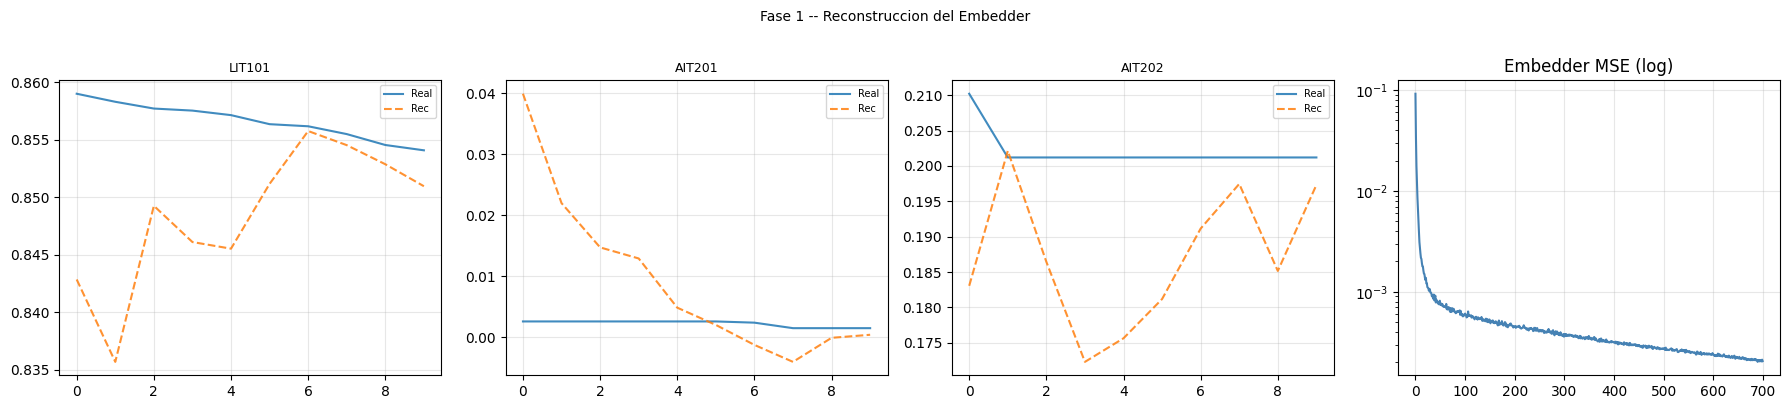

In [13]:
embedder_history = []
best_emb_mse   = float("inf")
best_emb_state_e = None
best_emb_state_r = None
emb_stopped_early = False

for epoch in range(epochs_embedder):
    ep = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        e_optimizer.zero_grad()
        loss = mse_loss(recovery(embedder(x)), x)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), 1.0)
        e_optimizer.step()
        ep += loss.item()
    ep /= len(train_loader)
    embedder_history.append(ep)

    # Early stopping: restaurar si MSE explota 5x por encima del mejor
    if ep < best_emb_mse:
        best_emb_mse     = ep
        best_emb_state_e = {k: v.cpu().clone() for k, v in embedder.state_dict().items()}
        best_emb_state_r = {k: v.cpu().clone() for k, v in recovery.state_dict().items()}
    elif ep > EMB_EARLY_STOP_FACTOR * best_emb_mse and epoch > 50:
        print(f"  [Early Stop] Epoch {epoch+1}: MSE={ep:.6f} > {EMB_EARLY_STOP_FACTOR}x "
              f"best={best_emb_mse:.6f}. Restaurando mejores pesos y deteniendo.")
        embedder.load_state_dict(best_emb_state_e)
        recovery.load_state_dict(best_emb_state_r)
        emb_stopped_early = True
        break

    if (epoch + 1) % 100 == 0:
        print(f"[Embedder] Epoch {epoch+1:4d}/{epochs_embedder} | MSE: {ep:.6f} "
              f"| Best: {best_emb_mse:.6f}")

mse_f = embedder_history[-1]
print(f"\nMSE final: {mse_f:.6f}  {chr(9989) if mse_f < 0.001 else chr(9888)}")
print(f"Mejor MSE: {best_emb_mse:.6f} | Stopped early: {emb_stopped_early}")
if emb_stopped_early:
    embedder_history[-1] = best_emb_mse
    print("Usando mejores pesos del embedder (pre-explosion) para el resto del pipeline.")

with torch.no_grad():
    xs = train_tensor[:64].to(device)
    xr = recovery(embedder(xs)).cpu().numpy()
    xo = xs.cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for idx in range(3):
    axes[idx].plot(xo[0,:,idx], label="Real",  alpha=0.85)
    axes[idx].plot(xr[0,:,idx], label="Rec",   alpha=0.85, linestyle="--")
    axes[idx].set_title(GAN_CONT_COLS[idx], fontsize=9)
    axes[idx].legend(fontsize=7); axes[idx].grid(True, alpha=0.3)
axes[3].semilogy(embedder_history, color="steelblue")
if emb_stopped_early:
    axes[3].axhline(best_emb_mse, color="green", linestyle="--", lw=1.5,
                    label=f"Best ({best_emb_mse:.6f})")
    axes[3].legend(fontsize=7)
axes[3].set_title("Embedder MSE (log)"); axes[3].grid(True, alpha=0.3)
plt.suptitle("Fase 1 -- Reconstruccion del Embedder", fontsize=10, y=1.01)
plt.tight_layout(); plt.show()


## D1. Diagnóstico del Embedder — Calidad de Reconstrucción

=== D1: DIAGNOSTICO EMBEDDER -- CALIDAD DE RECONSTRUCCION ===

Sensor                       MSE        RMSE  Estado
----------------------------------------------------
LIT101                  0.000271     0.01645  OK
AIT201                  0.000240     0.01549  OK
AIT202                  0.000186     0.01365  OK
AIT203                  0.000121     0.01101  OK
DPIT301                 0.000331     0.01821  OK
LIT301                  0.000242     0.01556  OK
AIT401                  0.000449     0.02118  OK
AIT402                  0.000148     0.01217  OK
LIT401                  0.000216     0.01469  OK
AIT501                  0.000151     0.01230  OK
AIT502                  0.000137     0.01171  OK
AIT503                  0.000171     0.01307  OK
AIT504                  0.000152     0.01233  OK
PIT501                  0.000183     0.01354  OK
PIT502                  0.000374     0.01934  OK
PIT503                  0.000162     0.01274  OK

MSE global: 0.000221 | RMSE global: 0.01487
Re

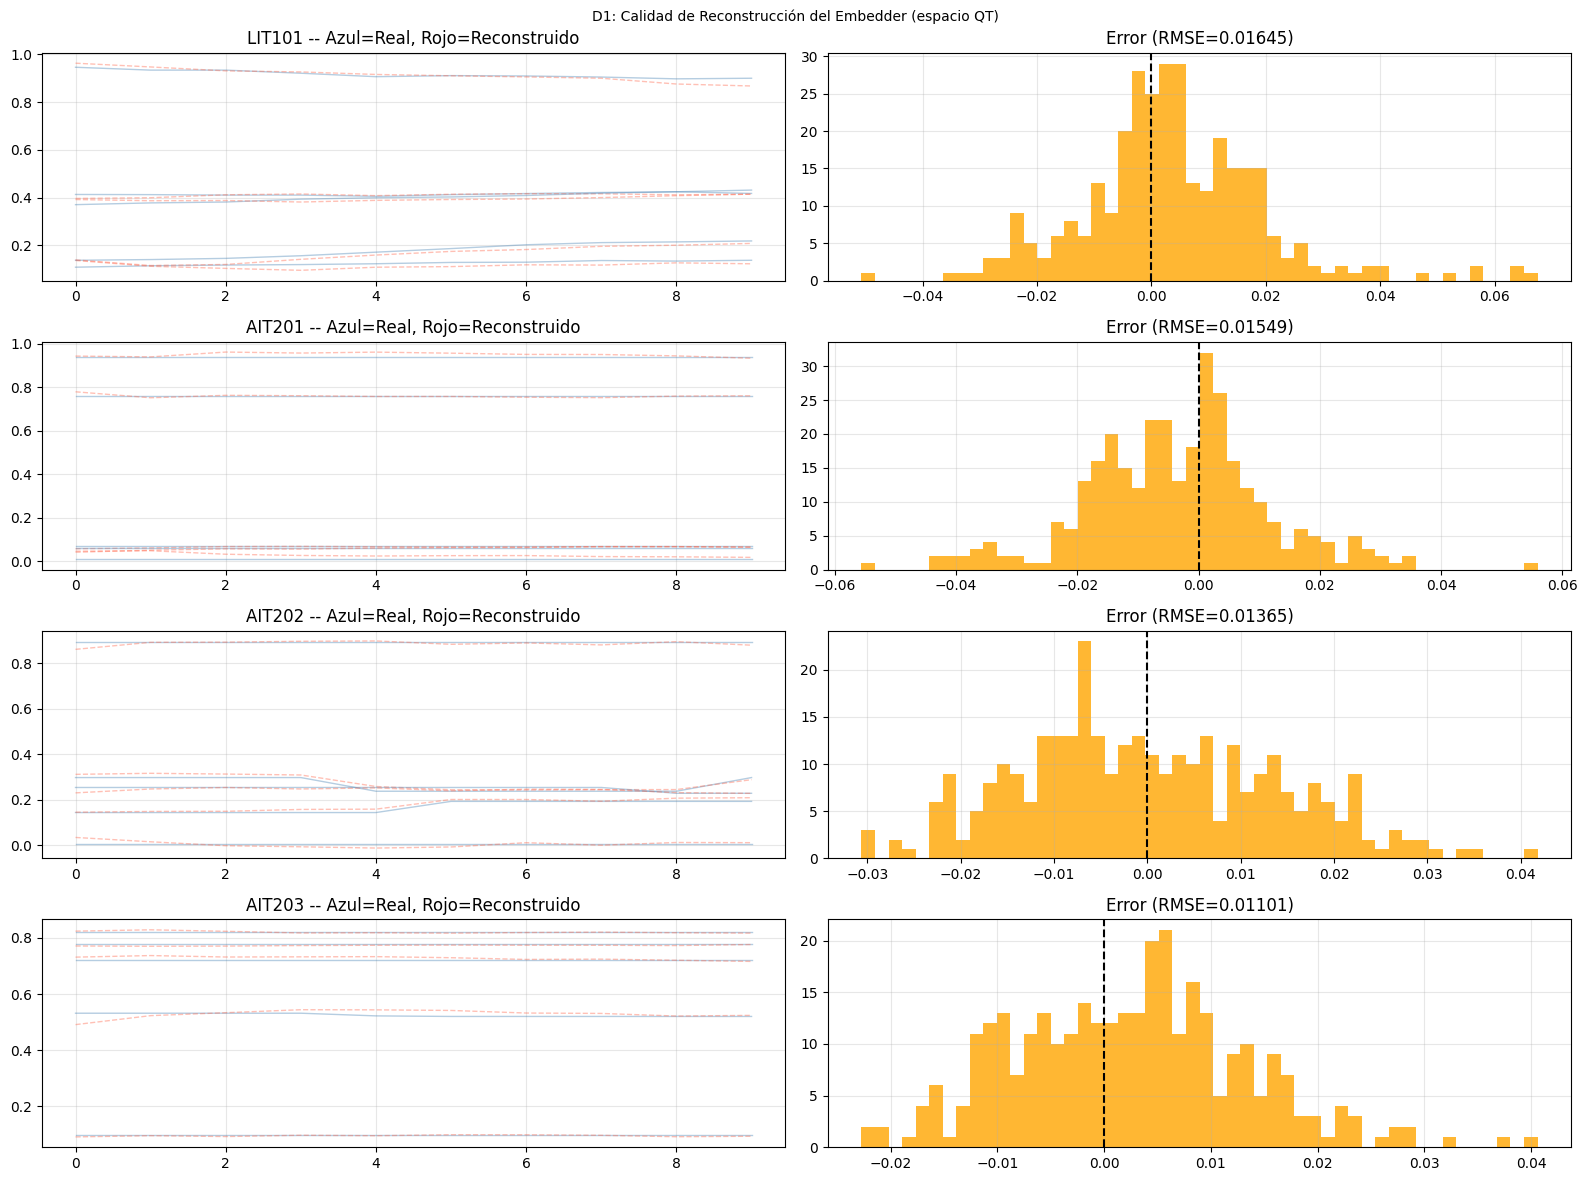

In [14]:
print("=== D1: DIAGNOSTICO EMBEDDER -- CALIDAD DE RECONSTRUCCION ===")
print()
with torch.no_grad():
    x_samp = next(iter(train_loader))[0][:32].to(device)
    h_samp  = embedder(x_samp)
    x_rec   = recovery(h_samp).cpu().numpy()
x_samp_np = x_samp.cpu().numpy()
mse_per = ((x_samp_np - x_rec)**2).mean(axis=(0,1))

print(f'{"Sensor":<20}  {"MSE":>10}  {"RMSE":>10}  Estado')
print("-" * 52)
for j, s in enumerate(GAN_CONT_COLS):
    rmse = mse_per[j]**0.5
    est  = "OK" if rmse < 0.05 else ("REVISAR" if rmse < 0.10 else "MAL")
    print(f'{s:<20}  {mse_per[j]:>10.6f}  {rmse:>10.5f}  {est}')
print()
print(f"MSE global: {mse_per.mean():.6f} | RMSE global: {mse_per.mean()**0.5:.5f}")
print(f"Referencia A7 v21 MSE final: 0.000121")

plot_s = [s for s in GAN_CONT_COLS if any(k in s for k in ["LIT","AIT","PIT"])][:4]
if plot_s:
    fig, axes = plt.subplots(len(plot_s), 2, figsize=(16, 3*len(plot_s)))
    if len(plot_s) == 1: axes = [axes]
    for k, s in enumerate(plot_s):
        j = GAN_CONT_COLS.index(s)
        for w in range(min(5, 32)):
            axes[k][0].plot(x_samp_np[w,:,j], alpha=0.4, lw=1, color="steelblue")
            axes[k][0].plot(x_rec[w,:,j],     alpha=0.4, lw=1, color="tomato", linestyle="--")
        axes[k][0].set_title(f"{s} -- Azul=Real, Rojo=Reconstruido"); axes[k][0].grid(True, alpha=0.3)
        diff = (x_samp_np[:,:,j] - x_rec[:,:,j]).flatten()
        axes[k][1].hist(diff, bins=50, color="orange", alpha=0.8)
        axes[k][1].axvline(0, color="black", lw=1.5, linestyle="--")
        axes[k][1].set_title(f"Error (RMSE={mse_per[j]**0.5:.5f})")
        axes[k][1].grid(True, alpha=0.3)
    plt.suptitle("D1: Calidad de Reconstrucción del Embedder (espacio QT)", fontsize=10)
    plt.tight_layout(); plt.show()


## 10b. Preentrenamiento del Generador (600 épocas) — kNN Assignment

Evita el cold-start del generador guiándolo hacia el espacio latente real
antes del entrenamiento adversarial.


=== PREENTRENAMIENTO DEL GENERADOR -- kNN ASSIGNMENT ===

h_real_all: torch.Size([11264, 10, 128]) | h_real_mean: torch.Size([11264, 128])
[G Pretrain kNN] Epoch 100/600 | loss: 0.004826
[G Pretrain kNN] Epoch 200/600 | loss: 0.005244
[G Pretrain kNN] Epoch 300/600 | loss: 0.004466
[G Pretrain kNN] Epoch 400/600 | loss: 0.004154
[G Pretrain kNN] Epoch 500/600 | loss: 0.003888
[G Pretrain kNN] Epoch 600/600 | loss: 0.004776

kNN loss inicial: 0.015324 | final: 0.004776
Reducción: 68.8%


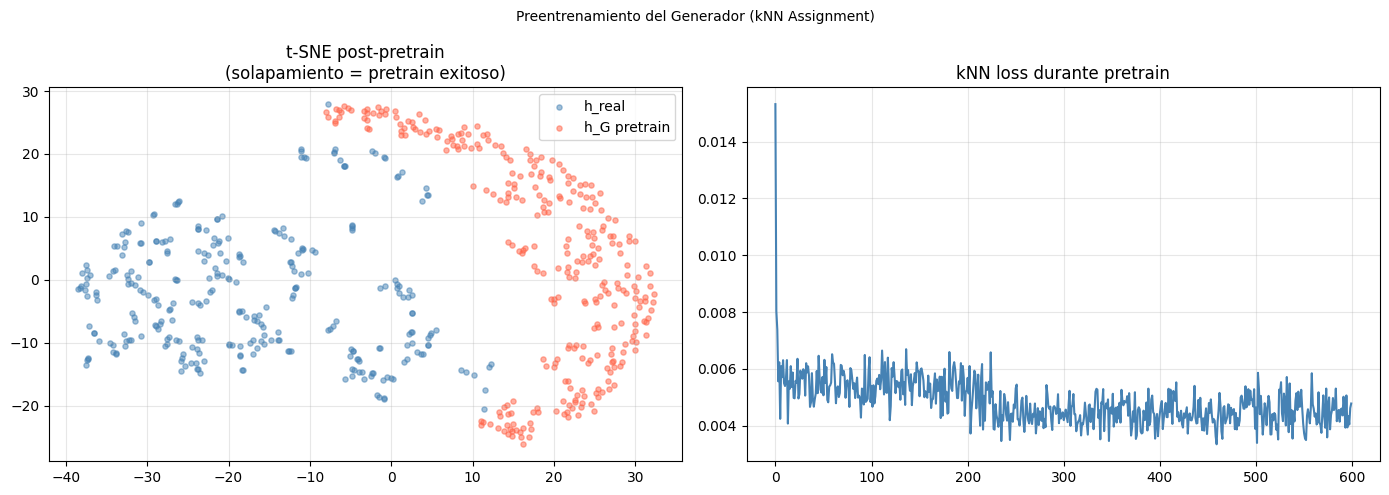

In [15]:
print("=== PREENTRENAMIENTO DEL GENERADOR -- kNN ASSIGNMENT ===")
print()
h_real_all_list = []
with torch.no_grad():
    for batch in train_loader:
        x_b = batch[0].to(device)
        h_real_all_list.append(embedder(x_b).cpu())
h_real_all  = torch.cat(h_real_all_list, dim=0)
h_real_mean = h_real_all.mean(dim=1)
print(f"h_real_all: {h_real_all.shape} | h_real_mean: {h_real_mean.shape}")

gen_pretrain_opt = torch.optim.Adam(generator.parameters(), lr=5e-3)
pretrain_history = []
rng_pretrain = np.random.default_rng(99)

for epoch in range(GEN_PRETRAIN_EPOCHS):
    ep_loss = 0.0; n_batches = 0
    for start in range(0, len(h_real_mean), BATCH_SIZE):
        end = min(start + BATCH_SIZE, len(h_real_mean)); bs = end - start
        z         = random_z_clipped(bs, seq_len, latent_dim, device)
        h_hat_mean = generator(z).mean(dim=1)
        k_idx  = rng_pretrain.choice(len(h_real_mean), 64, replace=False)
        h_cand = h_real_mean[k_idx].to(device)
        dists  = ((h_hat_mean.unsqueeze(1) - h_cand.unsqueeze(0)) ** 2).mean(dim=-1)
        loss   = dists.min(dim=1).values.mean()
        gen_pretrain_opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(generator.parameters(), G_CLIP)
        gen_pretrain_opt.step()
        ep_loss += loss.item(); n_batches += 1
    ep_loss /= n_batches; pretrain_history.append(ep_loss)
    if (epoch + 1) % 100 == 0:
        print(f"[G Pretrain kNN] Epoch {epoch+1}/{GEN_PRETRAIN_EPOCHS} | loss: {ep_loss:.6f}")

print(f"\nkNN loss inicial: {pretrain_history[0]:.6f} | final: {pretrain_history[-1]:.6f}")
print(f"Reducción: {100*(pretrain_history[0]-pretrain_history[-1])/max(pretrain_history[0],1e-10):.1f}%")

# t-SNE post-pretrain
import warnings; from sklearn.manifold import TSNE as _TSNE2
n_check = 300; rng_check = np.random.default_rng(7)
idx_check = rng_check.choice(len(h_real_all), n_check, replace=False)
h_real_s  = h_real_all[idx_check].mean(dim=1).numpy()
with torch.no_grad():
    z_chk   = random_z_clipped(n_check, seq_len, latent_dim, device)
    h_pre_s = generator(z_chk).cpu().mean(dim=1).numpy()
H_pre = np.vstack([h_real_s, h_pre_s])
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    H_pre_2d = _TSNE2(n_components=2, perplexity=20, random_state=42, max_iter=500).fit_transform(H_pre)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(H_pre_2d[:n_check,0], H_pre_2d[:n_check,1], c="steelblue", alpha=0.5, s=14, label="h_real")
axes[0].scatter(H_pre_2d[n_check:,0], H_pre_2d[n_check:,1], c="tomato",    alpha=0.5, s=14, label="h_G pretrain")
axes[0].set_title("t-SNE post-pretrain\n(solapamiento = pretrain exitoso)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(pretrain_history, color="steelblue", lw=1.5)
axes[1].set_title("kNN loss durante pretrain"); axes[1].grid(True, alpha=0.3)
plt.suptitle("Preentrenamiento del Generador (kNN Assignment)", fontsize=10)
plt.tight_layout(); plt.show()


## 11. Fase 2 — Preentrenamiento del Supervisor (600 épocas)

In [16]:
supervisor_history = []
for epoch in range(epochs_supervisor):
    ep = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        s_optimizer.zero_grad()
        with torch.no_grad(): h = embedder(x)
        hs   = supervisor(h)
        loss = mse_loss(h[:, 1:, :], hs[:, :-1, :])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(supervisor.parameters(), 1.0)
        s_optimizer.step()
        ep += loss.item()
    ep /= len(train_loader)
    supervisor_history.append(ep)
    if (epoch + 1) % 100 == 0:
        print(f"[Supervisor] Epoch {epoch+1:4d}/{epochs_supervisor} | Loss: {ep:.6f}")
sup_f = supervisor_history[-1]
print(f"\nLoss final: {sup_f:.6f}  {'✅' if sup_f < 0.005 else '⚠️ '}")


[Supervisor] Epoch  100/600 | Loss: 0.001896
[Supervisor] Epoch  200/600 | Loss: 0.001845
[Supervisor] Epoch  300/600 | Loss: 0.001803
[Supervisor] Epoch  400/600 | Loss: 0.001758
[Supervisor] Epoch  500/600 | Loss: 0.001714
[Supervisor] Epoch  600/600 | Loss: 0.001680

Loss final: 0.001680  ✅


## D2. Diagnóstico del Supervisor — Predicción Temporal

=== D2: DIAGNOSTICO SUPERVISOR -- PREDICCION TEMPORAL ===
Teacher-forced MSE: 0.002026
Free-run MSE:       0.003040
Ratio free/tf:      1.50x
Supervisor: EXCELENTE generalización temporal


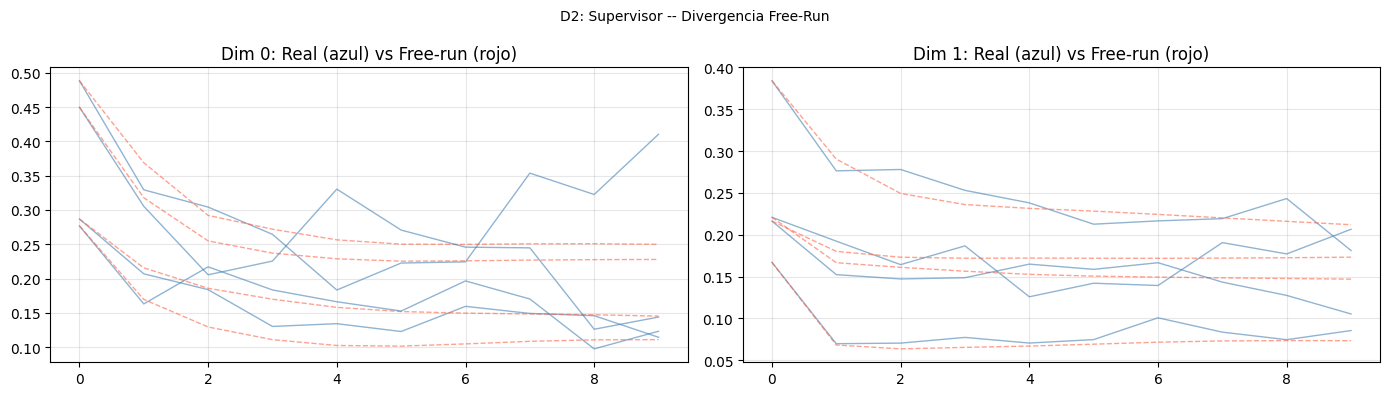

In [17]:
print("=== D2: DIAGNOSTICO SUPERVISOR -- PREDICCION TEMPORAL ===")
with torch.no_grad():
    x_b = next(iter(train_loader))[0][:16].to(device)
    h_b = embedder(x_b)
    h_pred_tf = supervisor(h_b)
    tf_loss   = ((h_b[:, 1:, :] - h_pred_tf[:, :-1, :])**2).mean().item()
    h_seq = h_b[:, :1, :]; preds = [h_seq]
    for _ in range(seq_len - 1):
        h_next = supervisor(h_seq)[:, -1:, :]; preds.append(h_next)
        h_seq  = torch.cat([h_seq, h_next], dim=1)
    h_free    = torch.cat(preds, dim=1)
    free_loss = ((h_b[:, 1:, :] - h_free[:, 1:, :])**2).mean().item()
ratio = free_loss / max(tf_loss, 1e-10)
print(f"Teacher-forced MSE: {tf_loss:.6f}")
print(f"Free-run MSE:       {free_loss:.6f}")
print(f"Ratio free/tf:      {ratio:.2f}x")
if ratio < 5:    print("Supervisor: EXCELENTE generalización temporal")
elif ratio < 15: print("Supervisor: ACEPTABLE generalización")
else:            print("Supervisor: ALERTA -- alta divergencia en free-run")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
h_b_np = h_b.cpu().numpy(); h_free_np = h_free.cpu().numpy()
for w in range(4):
    axes[0].plot(h_b_np[w,:,0], alpha=0.6, lw=1, color="steelblue")
    axes[0].plot(h_free_np[w,:,0], alpha=0.6, lw=1, color="tomato", linestyle="--")
axes[0].set_title("Dim 0: Real (azul) vs Free-run (rojo)"); axes[0].grid(True, alpha=0.3)
for w in range(4):
    axes[1].plot(h_b_np[w,:,1], alpha=0.6, lw=1, color="steelblue")
    axes[1].plot(h_free_np[w,:,1], alpha=0.6, lw=1, color="tomato", linestyle="--")
axes[1].set_title("Dim 1: Real (azul) vs Free-run (rojo)"); axes[1].grid(True, alpha=0.3)
plt.suptitle("D2: Supervisor -- Divergencia Free-Run", fontsize=10)
plt.tight_layout(); plt.show()


## 12. Fase 3 — Entrenamiento adversarial conjunto (6000 epocas)

**Objetivo:** que el Generator produzca series indistinguibles de las reales.

### Funcion de perdida del Generador

```
L_G = BCE(D(H_hat),1) + gamma x BCE(D(E_hat),1)
    + eta x ||h_{t+1} - S(h_t)||^2
    + FM_W x (||mu_r-mu_s||^2 + ||sigma_r-sigma_s||^2)
```

### Funcion de perdida del Discriminador

```
L_D = BCE(D(H_real),1) + BCE(D(H_fake),0) + gamma x BCE(D(E_hat),0)
    + R1_LAMBDA x R1_INTERVAL x ||nabla D(h_real)||^2
```

### Por que v2 deberia ser mas estable

Con 38 batches/epoca y R1_INTERVAL=16, el R1 se dispara 2.4x/epoca
(vs 14.4x en v1). La acumulacion de gradientes por ciclo es 6x menor,
y el discriminador recibe actualizaciones mucho mas granulares.

Con el Embedder convergido (objetivo: MSE<0.001), h_real es una representacion
fiel del espacio latente real. El kNN pretrain entrenara sobre h_real de calidad,
el Supervisor converge mejor, y el joint training deberia partir con G mas cercano
al Nash (G~1.4) en lugar de G=6.07 como en v1.

**Referencia A7 v21:** D=2.0751 (Nash exacto) | Spikes=104 | 29 batches/epoca
**v1 resultado:**      D=1.29                 | Spikes=1981 | 462 batches/epoca


In [18]:
def r1_penalty(disc, h_real):
    h_r  = h_real.detach().requires_grad_(True)
    y_r  = disc(h_r)
    grad = torch.autograd.grad(outputs=y_r.sum(), inputs=h_r,
                                create_graph=False, retain_graph=False)[0]
    return grad.pow(2).mean()

joint_g_history, joint_d_history, joint_e_history = [], [], []
batch_counter = 0

for epoch in range(epochs_joint):
    g_ep, d_ep, e_ep = 0.0, 0.0, 0.0
    for batch in train_loader:
        x  = batch[0].to(device); bs = x.shape[0]
        with torch.no_grad(): h_real = embedder(x)

        # G_STEPS
        g_loss_val = torch.tensor(0.0)
        for _ in range(G_STEPS):
            g_optimizer.zero_grad()
            z     = random_z_clipped(bs, seq_len, latent_dim, device)
            e_hat = generator(z); h_hat = supervisor(e_hat)
            y_f   = discriminator(h_hat); y_fe = discriminator(e_hat)
            g_u   = bce_loss(y_f,  torch.ones_like(y_f))
            g_ue  = bce_loss(y_fe, torch.ones_like(y_fe))
            with torch.no_grad(): h_sup = supervisor(h_real)
            g_s     = mse_loss(h_real[:, 1:, :].detach(), h_sup[:, :-1, :])
            fm_loss = (mse_loss(h_hat.mean(0), h_real.mean(0)) +
                       mse_loss(h_hat.std(0),  h_real.std(0)))
            g_loss  = g_u + gamma * g_ue + eta * g_s + FM_W * fm_loss
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(generator.parameters()) + list(supervisor.parameters()), G_CLIP)
            g_optimizer.step(); g_loss_val = g_loss

        # Embedder refinement
        e_optimizer.zero_grad()
        h_ref   = embedder(x); x_tilde = recovery(h_ref)
        h_sup_r = supervisor(h_ref.detach())
        e_loss  = lambda_r * mse_loss(x_tilde, x) + lambda_s * mse_loss(
            h_ref[:, 1:, :], h_sup_r[:, :-1, :])
        e_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), 1.0)
        e_optimizer.step()
        batch_counter += 1

        # D_STEPS con R1 lazy
        d_loss_val = torch.tensor(0.0)
        for _ in range(D_STEPS):
            d_optimizer.zero_grad()
            with torch.no_grad():
                z2     = random_z_clipped(bs, seq_len, latent_dim, device)
                e_hat2 = generator(z2); h_hat2 = supervisor(e_hat2)
            y_r   = discriminator(h_real)
            y_f2  = discriminator(h_hat2); y_fe2 = discriminator(e_hat2)
            r1 = (
                r1_penalty(discriminator, h_real)
                if batch_counter % R1_INTERVAL == 0
                else torch.tensor(0.0, device=device)
            )
            d_loss = (bce_loss(y_r,   torch.ones_like(y_r)) +
                      bce_loss(y_f2,  torch.zeros_like(y_f2)) +
                      gamma * bce_loss(y_fe2, torch.zeros_like(y_fe2)) +
                      R1_LAMBDA * R1_INTERVAL * r1)
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), D_CLIP)
            d_optimizer.step(); d_loss_val = d_loss

        g_ep += g_loss_val.item(); d_ep += d_loss_val.item(); e_ep += e_loss.item()

    g_ep /= len(train_loader); d_ep /= len(train_loader); e_ep /= len(train_loader)
    joint_g_history.append(g_ep); joint_d_history.append(d_ep); joint_e_history.append(e_ep)
    d_scheduler.step(d_ep)

    if (epoch + 1) % 100 == 0:
        g_prev = joint_g_history[-101] if len(joint_g_history) > 100 else joint_g_history[0]
        trend  = "↓" if g_ep < g_prev-0.05 else ("↑" if g_ep > g_prev+0.1 else "→")
        print(f"[Joint] Epoch {epoch+1:5d}/{epochs_joint} | "
              f"G: {g_ep:.4f}{trend} | D: {d_ep:.4f} | E: {e_ep:.6f}")


[Joint] Epoch   100/6000 | G: 1.4399↑ | D: 1.6685 | E: 0.004118
[Joint] Epoch   200/6000 | G: 1.3733↓ | D: 1.6872 | E: 0.002166
[Joint] Epoch   300/6000 | G: 1.3755→ | D: 1.6840 | E: 0.001670
[Joint] Epoch   400/6000 | G: 1.3750→ | D: 1.6830 | E: 0.001798
[Joint] Epoch   500/6000 | G: 1.3746→ | D: 1.6827 | E: 0.001280
[Joint] Epoch   600/6000 | G: 1.3745→ | D: 1.6830 | E: 0.002001
[Joint] Epoch   700/6000 | G: 1.3744→ | D: 1.6828 | E: 0.001360
[Joint] Epoch   800/6000 | G: 1.3738→ | D: 1.6826 | E: 0.000986
[Joint] Epoch   900/6000 | G: 1.3747→ | D: 1.6828 | E: 0.001422
[Joint] Epoch  1000/6000 | G: 1.3742→ | D: 1.6827 | E: 0.000786
[Joint] Epoch  1100/6000 | G: 1.3751→ | D: 1.6827 | E: 0.000895
[Joint] Epoch  1200/6000 | G: 1.3744→ | D: 1.6827 | E: 0.001100
[Joint] Epoch  1300/6000 | G: 1.3743→ | D: 1.6827 | E: 0.000730
[Joint] Epoch  1400/6000 | G: 1.3747→ | D: 1.6826 | E: 0.001176
[Joint] Epoch  1500/6000 | G: 1.3739→ | D: 1.6827 | E: 0.000828
[Joint] Epoch  1600/6000 | G: 1.3745→ | 

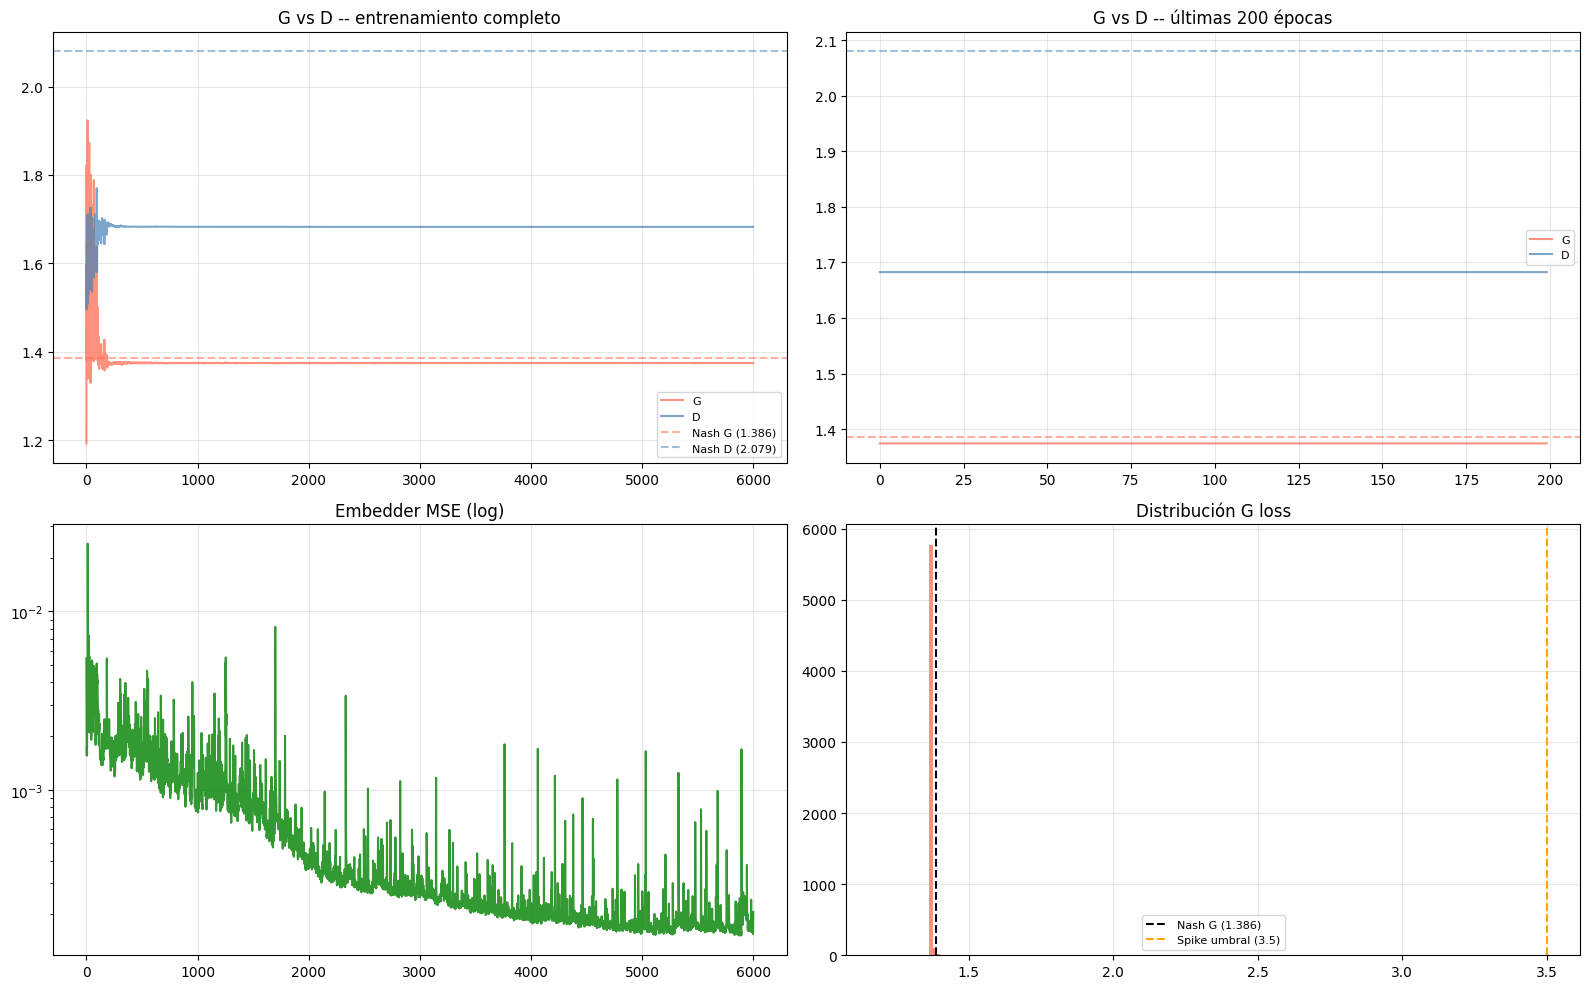

G inicial:    1.1926  (Nash G=1.3863)
G final:      1.3744
D final:      1.6825  (Nash D = 2.0794, gap=0.3969)
Spikes G>3.5: 0


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0,0].plot(joint_g_history, alpha=0.7, color="tomato",    label="G")
axes[0,0].plot(joint_d_history, alpha=0.7, color="steelblue", label="D")
axes[0,0].axhline(nash_g, color="tomato",    linestyle="--", alpha=0.5, label=f"Nash G ({nash_g:.3f})")
axes[0,0].axhline(nash_d, color="steelblue", linestyle="--", alpha=0.5, label=f"Nash D ({nash_d:.3f})")
axes[0,0].set_title("G vs D -- entrenamiento completo"); axes[0,0].legend(fontsize=8); axes[0,0].grid(True, alpha=0.3)
axes[0,1].plot(joint_g_history[-200:], alpha=0.7, color="tomato",    label="G")
axes[0,1].plot(joint_d_history[-200:], alpha=0.7, color="steelblue", label="D")
axes[0,1].axhline(nash_g, color="tomato", linestyle="--", alpha=0.5)
axes[0,1].axhline(nash_d, color="steelblue", linestyle="--", alpha=0.5)
axes[0,1].set_title("G vs D -- últimas 200 épocas"); axes[0,1].legend(fontsize=8); axes[0,1].grid(True, alpha=0.3)
axes[1,0].semilogy(joint_e_history, color="green", alpha=0.8)
axes[1,0].set_title("Embedder MSE (log)"); axes[1,0].grid(True, alpha=0.3)
axes[1,1].hist(joint_g_history, bins=60, color="tomato", alpha=0.7)
axes[1,1].axvline(nash_g, color="black",  linestyle="--", lw=1.5, label=f"Nash G ({nash_g:.3f})")
axes[1,1].axvline(3.5,    color="orange", linestyle="--", lw=1.5, label="Spike umbral (3.5)")
axes[1,1].set_title("Distribución G loss"); axes[1,1].legend(fontsize=8); axes[1,1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

g_f = joint_g_history[-1]; d_f = joint_d_history[-1]
spikes = sum(1 for g in joint_g_history if g > 3.5)
print(f"G inicial:    {joint_g_history[0]:.4f}  (Nash G={nash_g:.4f})")
print(f"G final:      {g_f:.4f}")
print(f"D final:      {d_f:.4f}  (Nash D = {nash_d:.4f}, gap={abs(d_f-nash_d):.4f})")
print(f"Spikes G>3.5: {spikes}")


## D3. Diagnóstico del Generador — t-SNE del Espacio Latente

=== D3: DIAGNOSTICO GENERADOR -- t-SNE ESPACIO LATENTE ===


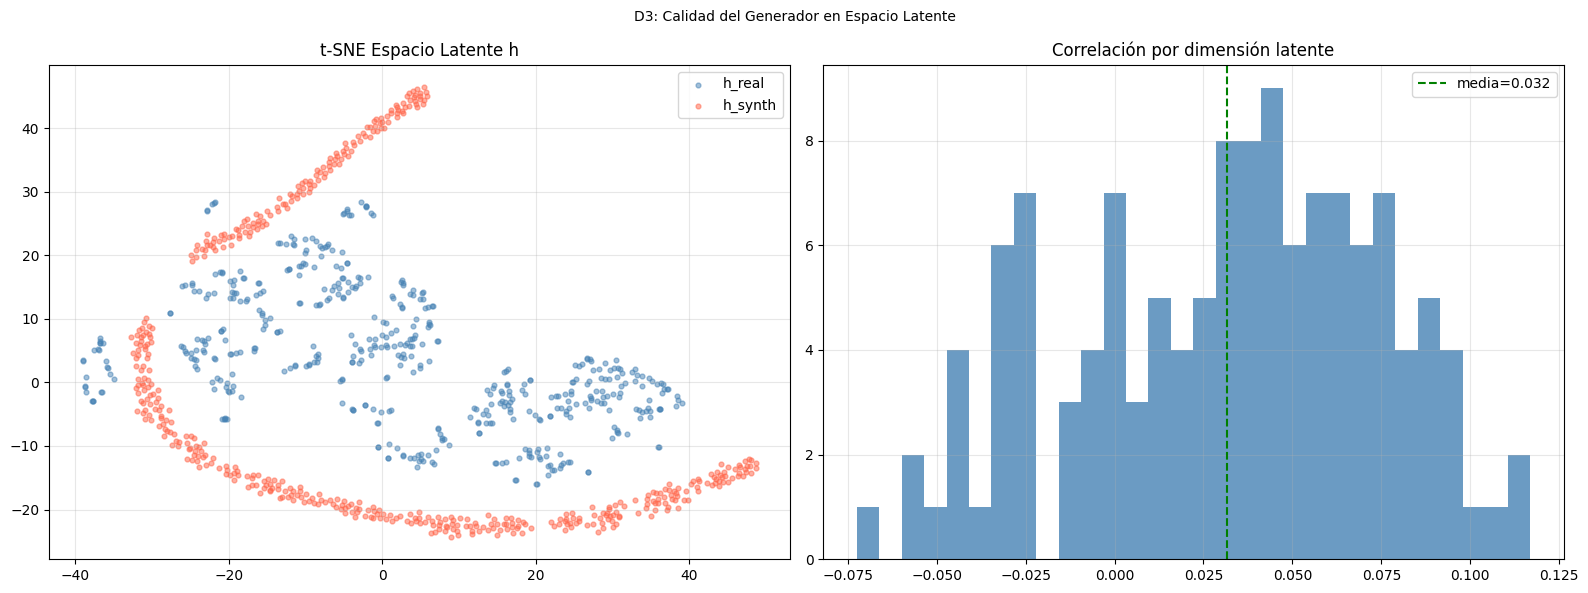

In [20]:
import warnings; from sklearn.manifold import TSNE as _TSNE
print("=== D3: DIAGNOSTICO GENERADOR -- t-SNE ESPACIO LATENTE ===")
n_lat = 500; rng_l = np.random.default_rng(42)
idx_l = rng_l.choice(len(train_windows), n_lat, replace=False)
with torch.no_grad():
    x_r = torch.tensor(train_windows[idx_l], dtype=torch.float32).to(device)
    h_r = embedder(x_r).cpu().numpy()
    z_s = random_z_clipped(n_lat, seq_len, latent_dim, device)
    h_s = supervisor(generator(z_s)).cpu().numpy()
hr_mp = h_r.mean(axis=1); hs_mp = h_s.mean(axis=1)
H_all = np.vstack([hr_mp, hs_mp]); y_all_lat = np.array([0]*n_lat + [1]*n_lat)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    H2d = _TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(H_all)
corr_dims = [np.corrcoef(hr_mp[:,d], hs_mp[:,d])[0,1] for d in range(hr_mp.shape[1])]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(H2d[y_all_lat==0,0], H2d[y_all_lat==0,1], c="steelblue", alpha=0.5, s=12, label="h_real")
axes[0].scatter(H2d[y_all_lat==1,0], H2d[y_all_lat==1,1], c="tomato",    alpha=0.5, s=12, label="h_synth")
axes[0].set_title("t-SNE Espacio Latente h"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].hist(corr_dims, bins=30, color="steelblue", alpha=0.8)
axes[1].axvline(np.mean(corr_dims), color="green", linestyle="--", lw=1.5,
                label=f"media={np.mean(corr_dims):.3f}")
axes[1].set_title("Correlación por dimensión latente"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle("D3: Calidad del Generador en Espacio Latente", fontsize=10)
plt.tight_layout(); plt.show()


## 13. Generación de datos sintéticos (espacio QT)

In [21]:
n_synth = 3 * len(train_windows)
synth_qt_list = []
with torch.no_grad():
    for start in range(0, n_synth, 256):
        end = min(start + 256, n_synth); bs = end - start
        z      = random_z_clipped(bs, seq_len, latent_dim, device)
        x_hat  = recovery(supervisor(generator(z))).cpu().numpy()
        synth_qt_list.append(x_hat)
synth_qt = np.concatenate(synth_qt_list, axis=0)

out_rng = ((synth_qt < -0.1) | (synth_qt > 1.1)).mean() * 100
print(f"synth_qt shape: {synth_qt.shape}")
print(f"Rango pre-clip: [{synth_qt.min():.4f}, {synth_qt.max():.4f}]")
print(f"Fuera de [-0.1, 1.1]: {out_rng:.2f}%  {'✅' if out_rng < 1.0 else '⚠️'}")
synth_qt_clipped = np.clip(synth_qt, 0.0, 1.0)
dm = abs(train_windows.mean() - synth_qt_clipped.mean())
ds = abs(train_windows.std()  - synth_qt_clipped.std())
print(f"Diff medias QT (pre-QM): {dm:.4f}  {'✅' if dm<0.05 else '⚠️'}")
print(f"Diff stds  QT (pre-QM): {ds:.4f}  {'✅' if ds<0.10 else '⚠️'}")


synth_qt shape: (33930, 10, 16)
Rango pre-clip: [-0.0184, 1.0461]
Fuera de [-0.1, 1.1]: 0.00%  ✅
Diff medias QT (pre-QM): 0.0031  ✅
Diff stds  QT (pre-QM): 0.0700  ✅


## D4. Diagnóstico Pre-QM — Drift por Sensor

=== D4: DIAGNOSTICO PRE-QM POR SENSOR ===

Sensor                     dm       ds    ratio  Estado
-------------------------------------------------------
LIT101                 0.0259   0.0980     3.97x  REVISAR
AIT201                 0.0339   0.0319    11.15x  MAL
AIT202                 0.0136   0.1252     3.07x  REVISAR
AIT203                 0.0330   0.0682    18.52x  MAL
DPIT301                0.0744   0.1283     0.63x  REVISAR
LIT301                 0.0384   0.0599     7.12x  MAL
AIT401                 0.0118   0.0501     1.46x  OK
AIT402                 0.0164   0.0869     4.80x  REVISAR
LIT401                 0.0108   0.0312     9.73x  MAL
AIT501                 0.0069   0.1012     5.03x  MAL
AIT502                 0.0316   0.0594     6.42x  MAL
AIT503                 0.0422   0.0243     7.09x  MAL
AIT504                 0.0187   0.0705     1.49x  OK
PIT501                 0.0018   0.1041     1.36x  REVISAR
PIT502                 0.0848   0.1574     0.78x  MAL
PIT503           

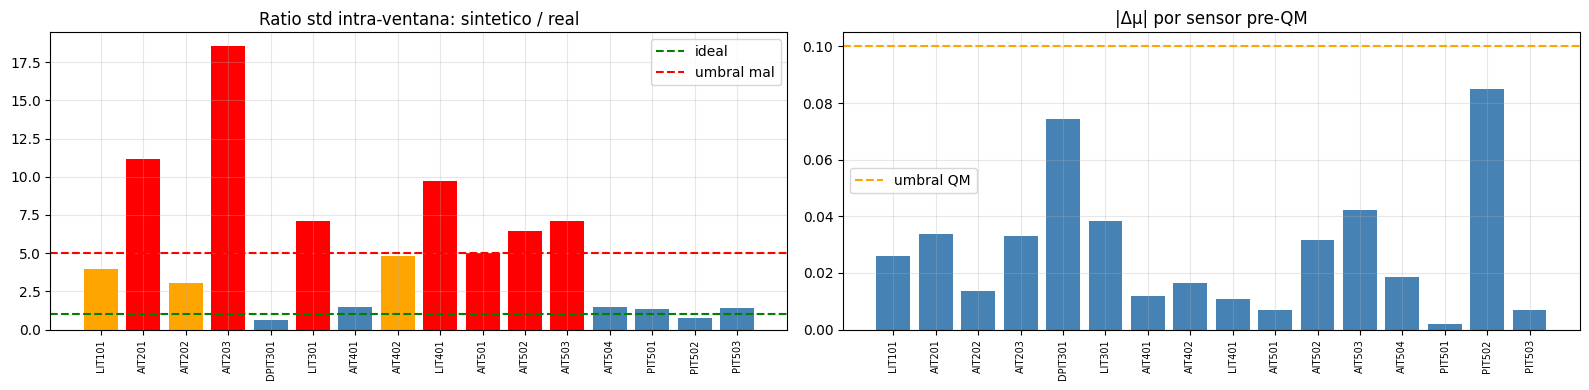

In [22]:
print("=== D4: DIAGNOSTICO PRE-QM POR SENSOR ==="); print()
_rf = train_windows.reshape(-1, len(GAN_CONT_COLS))
_sf = synth_qt_clipped.reshape(-1, len(GAN_CONT_COLS))
dm_p = np.abs(_rf.mean(0) - _sf.mean(0)); ds_p = np.abs(_rf.std(0) - _sf.std(0))
intra_r = train_windows.std(axis=1).mean(axis=0)
intra_s = synth_qt_clipped.std(axis=1).mean(axis=0)
ratio_i = intra_s / np.maximum(intra_r, 1e-8)
print(f'{"Sensor":<20}  {"dm":>7}  {"ds":>7}  {"ratio":>7}  Estado')
print("-" * 55)
for j, s in enumerate(GAN_CONT_COLS):
    if dm_p[j]>0.10 or ds_p[j]>0.15 or ratio_i[j]>5.0:  est = "MAL"
    elif dm_p[j]>0.05 or ds_p[j]>0.08 or ratio_i[j]>2.5: est = "REVISAR"
    else:                                                    est = "OK"
    print(f'{s:<20}  {dm_p[j]:>7.4f}  {ds_p[j]:>7.4f}  {ratio_i[j]:>7.2f}x  {est}')
n_mal = sum(1 for j in range(len(GAN_CONT_COLS)) if dm_p[j]>0.10 or ds_p[j]>0.15 or ratio_i[j]>5.0)
print(f"\nSensores MAL: {n_mal}/{len(GAN_CONT_COLS)} | dm global: {dm_p.mean():.4f}")
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
colors_b = ["red" if r>5 else ("orange" if r>2.5 else "steelblue") for r in ratio_i]
axes[0].bar(range(len(GAN_CONT_COLS)), ratio_i, color=colors_b)
axes[0].axhline(1.0, color="green",  linestyle="--", lw=1.5, label="ideal")
axes[0].axhline(5.0, color="red",    linestyle="--", lw=1.5, label="umbral mal")
axes[0].set_xticks(range(len(GAN_CONT_COLS)))
axes[0].set_xticklabels([s.replace(".Pv","") for s in GAN_CONT_COLS], rotation=90, fontsize=7)
axes[0].set_title("Ratio std intra-ventana: sintetico / real"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].bar(range(len(GAN_CONT_COLS)), dm_p, color=["red" if d>0.1 else "steelblue" for d in dm_p])
axes[1].axhline(0.10, color="orange", linestyle="--", lw=1.5, label="umbral QM")
axes[1].set_xticks(range(len(GAN_CONT_COLS)))
axes[1].set_xticklabels([s.replace(".Pv","") for s in GAN_CONT_COLS], rotation=90, fontsize=7)
axes[1].set_title("|Δμ| por sensor pre-QM"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 13b. Corrección de distribución marginal — Quantile Mapping

In [23]:
from scipy.stats import rankdata
CORR_MEAN_THR = 0.10; CORR_STD_THR = 0.15
_real_flat_pre  = train_windows.reshape(-1, len(GAN_CONT_COLS))
_synth_flat_pre = synth_qt_clipped.reshape(-1, len(GAN_CONT_COLS))
_dm_pre = np.abs(_real_flat_pre.mean(0) - _synth_flat_pre.mean(0))
_ds_pre = np.abs(_real_flat_pre.std(0)  - _synth_flat_pre.std(0))
CORRECTION_SENSORS = [GAN_CONT_COLS[j] for j in range(len(GAN_CONT_COLS))
                      if _dm_pre[j] > CORR_MEAN_THR or _ds_pre[j] > CORR_STD_THR]
print(f"Sensores para corrección: {len(CORRECTION_SENSORS)} / {len(GAN_CONT_COLS)}")
print(f"  {CORRECTION_SENSORS}")

def quantile_mapping(synth_col_flat, real_col_flat):
    real_sorted = np.sort(real_col_flat); n_real = len(real_sorted)
    ranks = rankdata(synth_col_flat, method="ordinal") - 1
    n_s   = len(synth_col_flat)
    idx   = np.clip((ranks / max(n_s-1,1) * (n_real-1)).astype(int), 0, n_real-1)
    return real_sorted[idx].astype(np.float32)

synth_qt_corrected = synth_qt_clipped.copy()
for sensor in CORRECTION_SENSORS:
    j = GAN_CONT_COLS.index(sensor)
    real_flat_col  = train_windows[:,:,j].flatten()
    synth_flat_col = synth_qt_corrected[:,:,j].flatten()
    dm_b = abs(real_flat_col.mean() - synth_flat_col.mean())
    corrected_flat = quantile_mapping(synth_flat_col, real_flat_col)
    synth_qt_corrected[:,:,j] = corrected_flat.reshape(synth_qt_clipped.shape[0], synth_qt_clipped.shape[1])
    dm_a = abs(real_flat_col.mean() - corrected_flat.mean())
    print(f"{sensor}: |dm| {dm_b:.4f} → {dm_a:.6f}")

_real_f = train_windows.reshape(-1, len(GAN_CONT_COLS)); _corr_f = synth_qt_corrected.reshape(-1, len(GAN_CONT_COLS))
print(f"\nDiff medias QT global -- antes: {np.abs(_real_flat_pre.mean(0)-_synth_flat_pre.mean(0)).mean():.4f}"
      f"  | después: {np.abs(_real_f.mean(0)-_corr_f.mean(0)).mean():.4f}")


Sensores para corrección: 1 / 16
  ['PIT502']
PIT502: |dm| 0.0849 → 0.000004

Diff medias QT global -- antes: 0.0282  | después: 0.0229


## 13c. Iman-Conover Correlation Remapping

=== IMAN-CONOVER CORRELATION REMAPPING ===

Diff media correlaciones: antes=0.3831  -> después=0.0375
Mejora: 90.2%


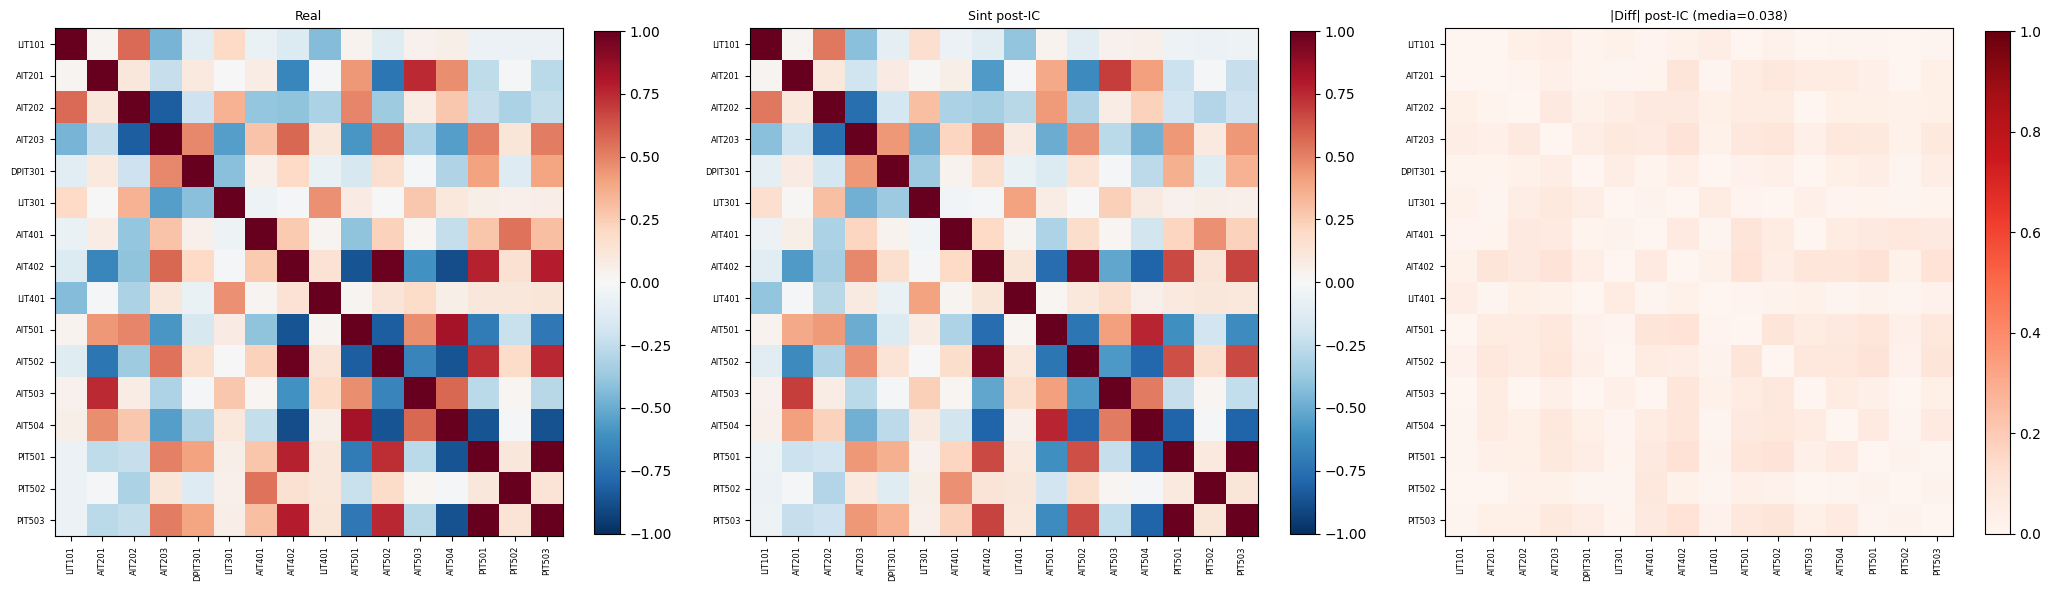

synth_qt_corrected actualizado con Iman-Conover.


In [24]:
from scipy.stats import rankdata as sp_rankdata
print("=== IMAN-CONOVER CORRELATION REMAPPING ==="); print()
N_ic, T_ic, F_ic = synth_qt_corrected.shape
synth_wmean = synth_qt_corrected.mean(axis=1); real_wmean = train_windows.mean(axis=1)
C_real_ic = np.corrcoef(real_wmean.T); C_real_ic = (C_real_ic + C_real_ic.T) / 2
jitter = 1e-6
for _ in range(10):
    try: L_ic = np.linalg.cholesky(C_real_ic + jitter * np.eye(F_ic)); break
    except np.linalg.LinAlgError: jitter *= 10
rng_ic = np.random.default_rng(42); Z_ic = rng_ic.standard_normal((N_ic, F_ic)); Z_corr = Z_ic @ L_ic.T
synth_qt_ic = np.zeros_like(synth_qt_corrected)
for j in range(F_ic):
    target_rank  = sp_rankdata(Z_corr[:,j], method="ordinal").astype(int) - 1
    order_current = np.argsort(synth_wmean[:,j])
    source_windows = order_current[target_rank]
    synth_qt_ic[:,:,j] = synth_qt_corrected[source_windows,:,j]
synth_wmean_after = synth_qt_ic.mean(axis=1)
C_synth_before = np.corrcoef(synth_wmean.T); C_synth_after = np.corrcoef(synth_wmean_after.T)
diff_before = np.abs(C_real_ic - C_synth_before).mean(); diff_after = np.abs(C_real_ic - C_synth_after).mean()
print(f"Diff media correlaciones: antes={diff_before:.4f}  -> después={diff_after:.4f}")
print(f"Mejora: {100*(diff_before-diff_after)/max(diff_before,1e-10):.1f}%")
labs_ic = [s.replace(".Pv","") for s in GAN_CONT_COLS]
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
for ax, data, title in zip(axes, [C_real_ic, C_synth_after, np.abs(C_real_ic-C_synth_after)],
                             ["Real", "Sint post-IC", f"|Diff| post-IC (media={diff_after:.3f})"]):
    vmin, vmax = (-1,1) if "Diff" not in title else (0,1)
    cmap = "RdBu_r" if "Diff" not in title else "Reds"
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9)
    ax.set_xticks(range(F_ic)); ax.set_xticklabels(labs_ic, rotation=90, fontsize=6)
    ax.set_yticks(range(F_ic)); ax.set_yticklabels(labs_ic, fontsize=6)
    plt.colorbar(im, ax=ax, shrink=0.75)
plt.tight_layout(); plt.show()
synth_qt_corrected = synth_qt_ic
print("synth_qt_corrected actualizado con Iman-Conover.")


## D5. Diagnóstico Post-QM — Matriz de Correlación Cruzada

=== D5: MATRIZ DE CORRELACION CRUZADA REAL vs SINTETICO ===



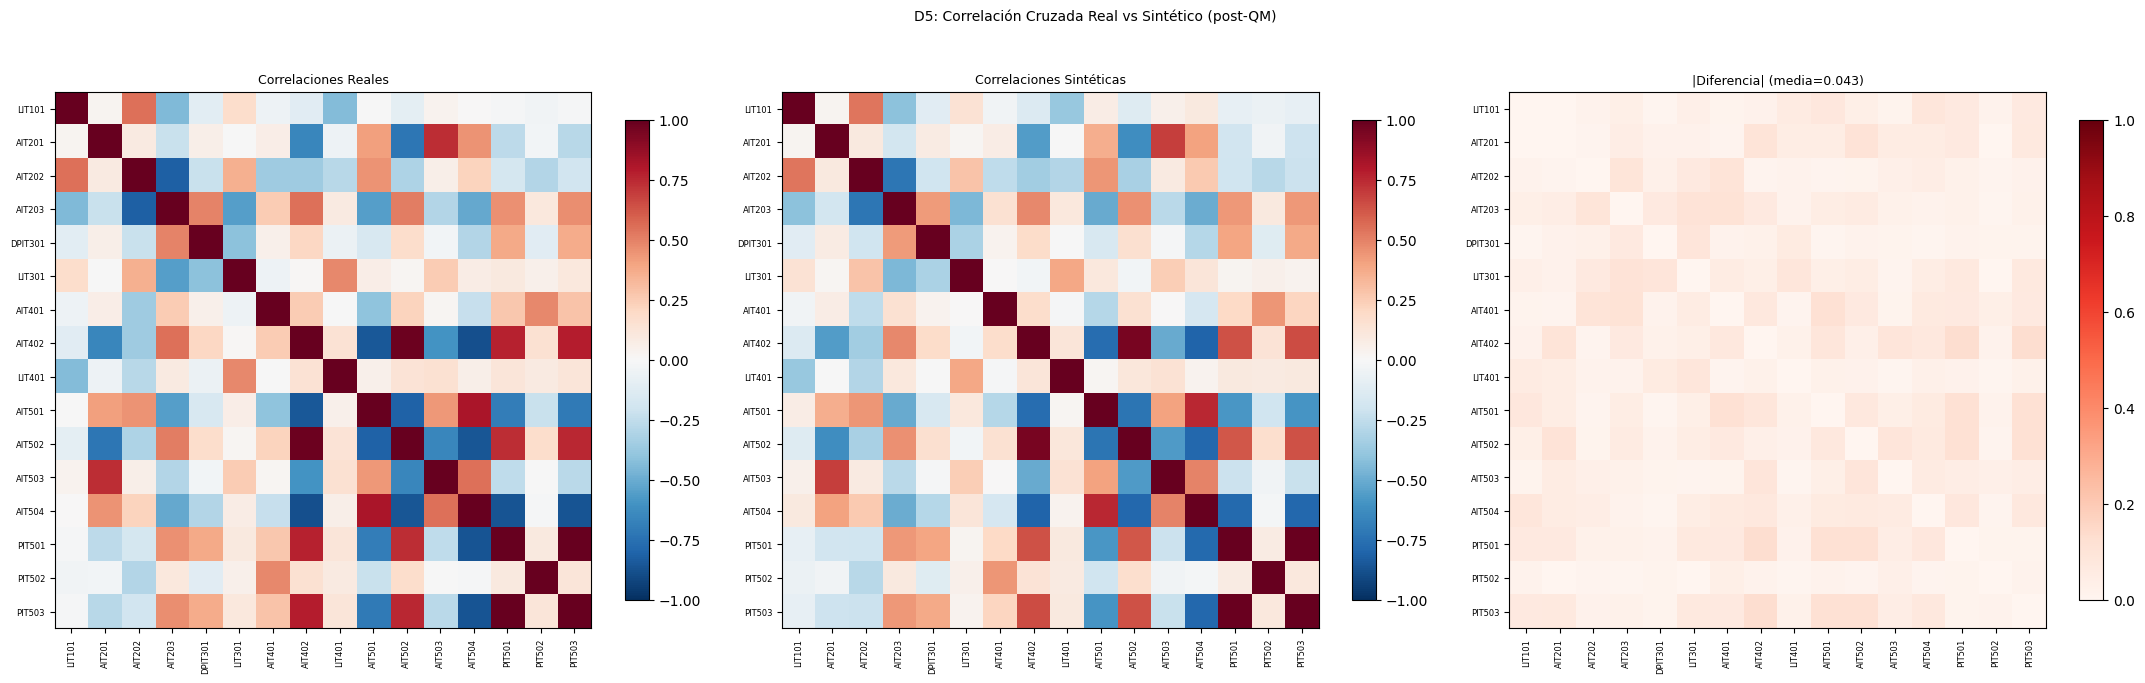

Diferencia media: 0.0427  (ideal: < 0.10)
Diferencia máxima: 0.1303


In [25]:
print("=== D5: MATRIZ DE CORRELACION CRUZADA REAL vs SINTETICO ==="); print()
n_cc = min(2000, len(train_windows)); rng_cc = np.random.default_rng(99)
idx_cc = rng_cc.choice(len(train_windows), n_cc, replace=False)
real_cc  = train_windows[idx_cc].reshape(-1, len(GAN_CONT_COLS))
synth_cc = synth_qt_corrected[idx_cc].reshape(-1, len(GAN_CONT_COLS))
corr_r = np.corrcoef(real_cc.T); corr_s = np.corrcoef(synth_cc.T); corr_d = np.abs(corr_r - corr_s)
labs = [s.replace(".Pv","") for s in GAN_CONT_COLS]
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, data, title in zip(axes, [corr_r, corr_s, corr_d],
    ["Correlaciones Reales","Correlaciones Sintéticas",f"|Diferencia| (media={corr_d.mean():.3f})"]):
    vmin, vmax = (-1,1) if "Diferencia" not in title else (0,1)
    cmap = "RdBu_r" if "Diferencia" not in title else "Reds"
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9)
    ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs, rotation=90, fontsize=6)
    ax.set_yticks(range(len(labs))); ax.set_yticklabels(labs, fontsize=6)
    plt.colorbar(im, ax=ax, shrink=0.75)
plt.suptitle("D5: Correlación Cruzada Real vs Sintético (post-QM)", fontsize=10)
plt.tight_layout(); plt.show()
print(f"Diferencia media: {corr_d.mean():.4f}  (ideal: < 0.10)")
print(f"Diferencia máxima: {corr_d.max():.4f}")


## 13d. Detrending Soft — LIT, AIT, PIT

In [26]:
from scipy.signal import detrend as scipy_detrend
SLOW_SENSORS_QT = [s for s in GAN_CONT_COLS if s.startswith("LIT") or s.startswith("AIT") or s.startswith("PIT")]
real_intra_std_qt = {s: float(train_windows[:,:,GAN_CONT_COLS.index(s)].std(axis=1).mean()) for s in SLOW_SENSORS_QT}
print(f"=== DETRENDING SOFT ({len(SLOW_SENSORS_QT)} sensores) ===")
synth_qt_detrended = synth_qt_corrected.copy()
windows_intervened = {s: 0 for s in SLOW_SENSORS_QT}
for s in SLOW_SENSORS_QT:
    j = GAN_CONT_COLS.index(s)
    target_std = real_intra_std_qt[s]; threshold = DETREND_FACTOR * target_std; rescale_to = DETREND_TARGET * target_std
    for w in range(synth_qt_detrended.shape[0]):
        win = synth_qt_detrended[w,:,j].copy()
        if win.std() > threshold:
            win_mean = win.mean(); detrended = scipy_detrend(win); curr_std = detrended.std()
            if curr_std > 1e-8: detrended = detrended * (rescale_to / curr_std)
            synth_qt_detrended[w,:,j] = np.clip(detrended + win_mean, 0.0, 1.0)
            windows_intervened[s] += 1
total_w = synth_qt_detrended.shape[0]
print(f'{"Sensor":<20}  {"real_std":>9}  {"synth_post":>12}  {"ratio":>7}  {"intervenidas":>14}')
print("-" * 70)
for s in SLOW_SENSORS_QT:
    j = GAN_CONT_COLS.index(s)
    synth_post = float(synth_qt_detrended[:,:,j].std(axis=1).mean())
    ratio = synth_post / max(real_intra_std_qt[s], 1e-8)
    n_int = windows_intervened[s]
    print(f'{s:<20}  {real_intra_std_qt[s]:>9.5f}  {synth_post:>12.5f}  {ratio:>7.3f}  {n_int:>6}/{total_w}')
synth_qt_corrected = synth_qt_detrended
print("\nsynth_qt_corrected actualizado con detrending soft.")


=== DETRENDING SOFT (15 sensores) ===
Sensor                 real_std    synth_post    ratio    intervenidas
----------------------------------------------------------------------
LIT101                  0.00654       0.00877    1.340   20991/33930
AIT201                  0.00191       0.00221    1.156   30513/33930
AIT202                  0.01010       0.01461    1.447   12822/33930
AIT203                  0.00210       0.00232    1.109   32079/33930
LIT301                  0.00289       0.00345    1.195   25715/33930
AIT401                  0.00852       0.00807    0.946    5394/33930
AIT402                  0.00308       0.00414    1.343   22245/33930
LIT401                  0.00235       0.00268    1.140   31025/33930
AIT501                  0.00340       0.00488    1.437   19218/33930
AIT502                  0.00223       0.00293    1.310   24881/33930
AIT503                  0.00277       0.00351    1.269   26914/33930
AIT504                  0.01403       0.01837    1.310    220

## D6. Diagnóstico Temporal — Autocorrelación Intra-Ventana

=== D6: DIAGNOSTICO TEMPORAL -- AUTOCORRELACION INTRA-VENTANA ===

Sensor                 ACF1_real   ACF1_sint      diff  Estado
------------------------------------------------------------
LIT101                    0.9999      0.9988    0.0011  OK
AIT201                    0.9998      1.0000    0.0002  OK
AIT202                    0.9993      0.9946    0.0047  OK
AIT203                    0.9999      0.9999    0.0000  OK
DPIT301                   0.9900      0.9928    0.0028  OK
LIT301                    0.9999      0.9999    0.0001  OK
AIT401                    0.9826      0.9989    0.0163  OK
AIT402                    0.9998      0.9998    0.0000  OK
LIT401                    1.0000      0.9999    0.0001  OK
AIT501                    0.9997      0.9995    0.0002  OK
AIT502                    0.9999      0.9999    0.0000  OK
AIT503                    0.9999      0.9999    0.0000  OK
AIT504                    0.9959      0.9965    0.0006  OK
PIT501                    0.9991      0.99

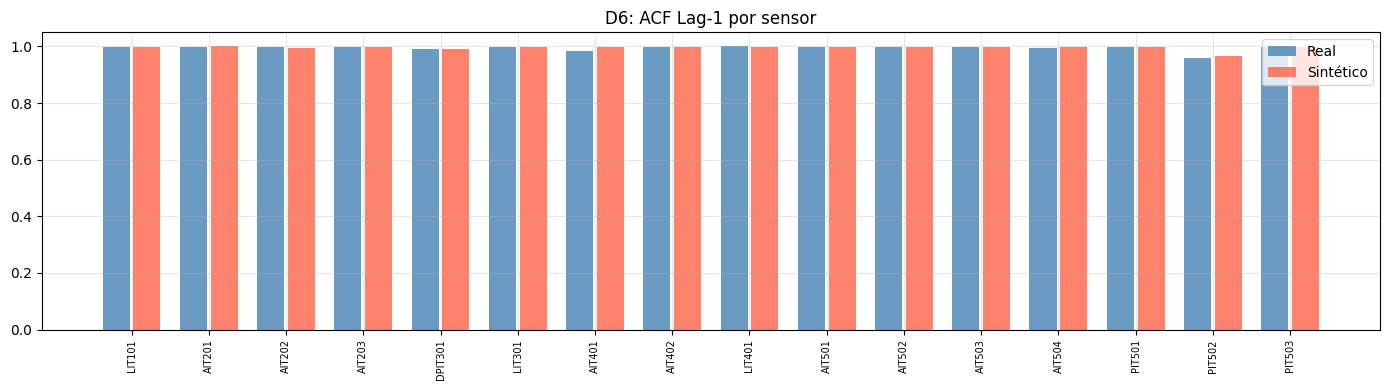

In [27]:
print("=== D6: DIAGNOSTICO TEMPORAL -- AUTOCORRELACION INTRA-VENTANA ==="); print()
def acf1(windows_3d):
    x = windows_3d; lag0 = x[:,:-1,:]; lag1 = x[:,1:,:]
    return np.array([np.corrcoef(lag0[:,:,j].flatten(), lag1[:,:,j].flatten())[0,1]
                     for j in range(x.shape[2])])
acf_r = acf1(train_windows); acf_s = acf1(synth_qt_corrected); acf_d = np.abs(acf_r - acf_s)
print(f'{"Sensor":<20}  {"ACF1_real":>10}  {"ACF1_sint":>10}  {"diff":>8}  Estado')
print("-" * 60)
for j, s in enumerate(GAN_CONT_COLS):
    est = "OK" if acf_d[j]<0.10 else ("REVISAR" if acf_d[j]<0.25 else "MAL")
    print(f'{s:<20}  {acf_r[j]:>10.4f}  {acf_s[j]:>10.4f}  {acf_d[j]:>8.4f}  {est}')
print(f"\nACF1 diff media: {acf_d.mean():.4f}  (ideal: < 0.05)")
fig, ax = plt.subplots(figsize=(14, 4))
x_pos = np.arange(len(GAN_CONT_COLS))
ax.bar(x_pos-0.2, acf_r, 0.35, color="steelblue", alpha=0.8, label="Real")
ax.bar(x_pos+0.2, acf_s, 0.35, color="tomato",    alpha=0.8, label="Sintético")
ax.set_xticks(x_pos); ax.set_xticklabels([s.replace(".Pv","") for s in GAN_CONT_COLS], rotation=90, fontsize=7)
ax.set_ylim(0, 1.05); ax.set_title("D6: ACF Lag-1 por sensor"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 14. Síntesis final — Ensamblaje de datos sintéticos

Inverse transform → escala física → FITs empíricos → discretas empíricas →
escalado con scaler_cont del detector → formato LSTM-VAE `(N, T, C)`.


In [28]:
n_gan = len(GAN_CONT_COLS)
synth_qt_flat  = synth_qt_corrected.reshape(-1, n_gan)
synth_gan_phys = qt.inverse_transform(synth_qt_flat).reshape(synth_qt_clipped.shape)

def synthesize_fit_windows(n_windows, window_size, fit_cols, fit_empirical, seed=42):
    rng = np.random.default_rng(seed)
    windows = np.zeros((n_windows, window_size, len(fit_cols)), dtype=np.float32)
    for j, col in enumerate(fit_cols):
        p0 = fit_empirical[col]["p_zero"]
        fo = np.array(fit_empirical[col]["flow_open"], dtype=np.float32)
        for i in range(n_windows):
            state = 0 if rng.random() < p0 else 1
            for t in range(window_size):
                if rng.random() >= 0.97: state = 0 if rng.random() < p0 else 1
                windows[i,t,j] = 0.0 if state == 0 else float(rng.choice(fo))
    return windows

def synthesize_disc_windows(n_windows, window_size, discrete_cols, disc_empirical, seed=42):
    rng = np.random.default_rng(seed)
    windows = np.zeros((n_windows, window_size, len(discrete_cols)), dtype=np.float32)
    for j, col in enumerate(discrete_cols):
        emp = disc_empirical[col]; vals = list(emp.keys()); probs = list(emp.values())
        for i in range(n_windows):
            windows[i,0,j] = rng.choice(vals, p=probs)
            for t in range(1, window_size):
                windows[i,t,j] = windows[i,t-1,j] if rng.random() < 0.95 else rng.choice(vals, p=probs)
    return windows

synth_fit_raw  = synthesize_fit_windows(n_synth, WINDOW_SIZE, FIT_BIMODAL_COLS, fit_empirical, SEED)
synth_disc_raw = synthesize_disc_windows(n_synth, WINDOW_SIZE, DISCRETE_COLS, disc_empirical, SEED)

print("Verificación P(0) FITs sintetizados:")
for j, col in enumerate(FIT_BIMODAL_COLS):
    p0_real = fit_empirical[col]["p_zero"]; p0_synth = (synth_fit_raw[:,:,j] == 0.0).mean()
    ok = "✅" if abs(p0_real - p0_synth) < 0.02 else "⚠️"
    print(f"  {ok} {col}: real={p0_real:.3f}, sint={p0_synth:.3f}")


Verificación P(0) FITs sintetizados:
  ✅ FIT101: real=0.276, sint=0.274
  ✅ FIT201: real=0.252, sint=0.255
  ✅ FIT301: real=0.149, sint=0.148
  ✅ FIT401: real=0.000, sint=0.000
  ✅ FIT501: real=0.000, sint=0.000
  ✅ FIT502: real=0.000, sint=0.000
  ✅ FIT503: real=0.000, sint=0.000
  ✅ FIT504: real=0.000, sint=0.000
  ✅ FIT601: real=0.315, sint=0.315


In [29]:
# ── Construir array completo en orden del detector (CONTINUOUS_COLS 25-dim) ──
synth_all_phys = np.zeros((n_synth, WINDOW_SIZE, len(CONTINUOUS_COLS)), dtype=np.float32)
for j, col in enumerate(GAN_CONT_COLS):
    synth_all_phys[:,:,CONTINUOUS_COLS.index(col)] = synth_gan_phys[:,:,j]
for j, col in enumerate(FIT_BIMODAL_COLS):
    if col in CONTINUOUS_COLS:
        synth_all_phys[:,:,CONTINUOUS_COLS.index(col)] = synth_fit_raw[:,:,j]
print(f"synth_all_phys: {synth_all_phys.shape}  (N, T=10, 25 sensores fisicos)")

# ── Aplicar Feature Engineering (RWSF + TF) para compatibilidad con baseline_v3
# ──────────────────────────────────────────────────────────────────────────────
# Estrategia: concatenar las N ventanas sintéticas en una serie temporal continua
# (N*10 timesteps), aplicar FE con la misma funcion del baseline, y re-extraer
# ventanas de 10 pasos. Las estadísticas RWSF capturan el comportamiento promedio
# de la serie sintetica; los primeros RWSF_WINDOW=120 pasos tienen estadísticas
# parciales (min_periods=1), lo cual es aceptable dado el volumen de datos.

print("\nAplicando Feature Engineering a serie sintetica...")
synth_ts = pd.DataFrame(
    synth_all_phys.reshape(-1, len(CONTINUOUS_COLS)),
    columns=CONTINUOUS_COLS
)

def add_feat_eng_synth(df):
    """Misma funcion FE que en baseline_v3."""
    df = df.copy()
    for s in SEASONAL_SENSORS:
        if s not in df.columns: continue
        r = df[s].rolling(RWSF_WINDOW, min_periods=1)
        df[f'{s}_roll_mean']   = r.mean()
        df[f'{s}_roll_median'] = r.median()
        df[f'{s}_roll_std']    = r.std().fillna(0)
        df[f'{s}_roll_max']    = r.max()
        df[f'{s}_roll_min']    = r.min()
    for s in SEASONAL_SENSORS:
        if s not in df.columns: continue
        for lag in TF_LAGS:
            df[f'{s}_lag_{lag}'] = df[s].shift(lag).bfill()
    return df

synth_ts_fe = add_feat_eng_synth(synth_ts)
print(f"  Serie sintetica FE: {synth_ts_fe.shape}  ({n_synth*WINDOW_SIZE:,} timesteps x {len(CONT_FEAT_COLS)} features)")

# Escalar con scaler_cont del baseline_v3 (ajustado en 89 features)
synth_scaled_89 = np.clip(
    scaler_cont.transform(synth_ts_fe[CONT_FEAT_COLS].values),
    -CLIP_VAL, CLIP_VAL
).astype(np.float32)

# Re-extraer ventanas de 10 pasos (stride=10 -> exactamente N ventanas)
synth_cont_wins = [
    synth_scaled_89[i:i+WINDOW_SIZE]
    for i in range(0, len(synth_scaled_89) - WINDOW_SIZE + 1, WINDOW_SIZE)
]
X_synth_cont = np.array(synth_cont_wins, dtype=np.float32)  # (N, 10, 89)

def summarize_disc_windows_final(disc_raw, dcols):
    rows = []
    for w in disc_raw:
        feats = {}
        for j, col in enumerate(dcols):
            v = w[:,j]; s = pd.Series(v)
            feats[f"{col}__mode"]        = s.mode().iloc[0] if len(s.mode()) > 0 else 0.0
            feats[f"{col}__transitions"] = float(np.sum(v[1:] != v[:-1]))
            feats[f"{col}__nunique"]     = float(len(np.unique(v)))
            feats[f"{col}__dominance"]   = float(s.value_counts(normalize=True).iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)

synth_disc_summary = summarize_disc_windows_final(synth_disc_raw, DISCRETE_COLS)

# X_synth_disc: summary stats de ventanas discretas (sin cambio)
X_synth_disc = synth_disc_summary.values.astype(np.float32)  # (N, 104)

# Trim para que N sea identico en cont y disc
n_final = min(len(X_synth_cont), len(X_synth_disc))
X_synth_cont = X_synth_cont[:n_final]
X_synth_disc = X_synth_disc[:n_final]

print(f"\nShapes finales (compatibles con baseline_v3):")
print(f"  X_synth_cont: {X_synth_cont.shape}  (N, T=10, C=89)")
print(f"  X_synth_disc: {X_synth_disc.shape}  (N, disc_dim=104)")
assert X_synth_cont.shape[1] == WINDOW_SIZE, f"ERROR: T={X_synth_cont.shape[1]} != {WINDOW_SIZE}"
assert X_synth_cont.shape[2] == len(CONT_FEAT_COLS), f"ERROR: C={X_synth_cont.shape[2]} != {len(CONT_FEAT_COLS)}"
assert X_synth_disc.shape[1] == DISC_DIM, f"ERROR: disc={X_synth_disc.shape[1]} != {DISC_DIM}"
print("Shapes OK -- compatible con HybridLSTMVAE.forward(xc, xd) en baseline_v3")

# Verificacion estadistica post-FE
rc = X_synth_cont[:, :, :25].mean()   # originales
rf = X_synth_cont[:, :, 25:65].mean() # RWSF
rt = X_synth_cont[:, :, 65:].mean()   # TF
print(f"\nMedia escalada -- Orig: {rc:.4f} | RWSF: {rf:.4f} | TF: {rt:.4f}  (esperado: ~0)")


synth_all_phys: (33930, 10, 25)  (N, T=10, 25 sensores fisicos)

Aplicando Feature Engineering a serie sintetica...
  Serie sintetica FE: (339300, 89)  (339,300 timesteps x 89 features)

Shapes finales (compatibles con baseline_v3):
  X_synth_cont: (33930, 10, 89)  (N, T=10, C=89)
  X_synth_disc: (33930, 104)  (N, disc_dim=104)
Shapes OK -- compatible con HybridLSTMVAE.forward(xc, xd) en baseline_v3

Media escalada -- Orig: 0.0197 | RWSF: 0.5797 | TF: 0.0101  (esperado: ~0)


## 15. Evaluación de calidad distribucional: PCA y t-SNE

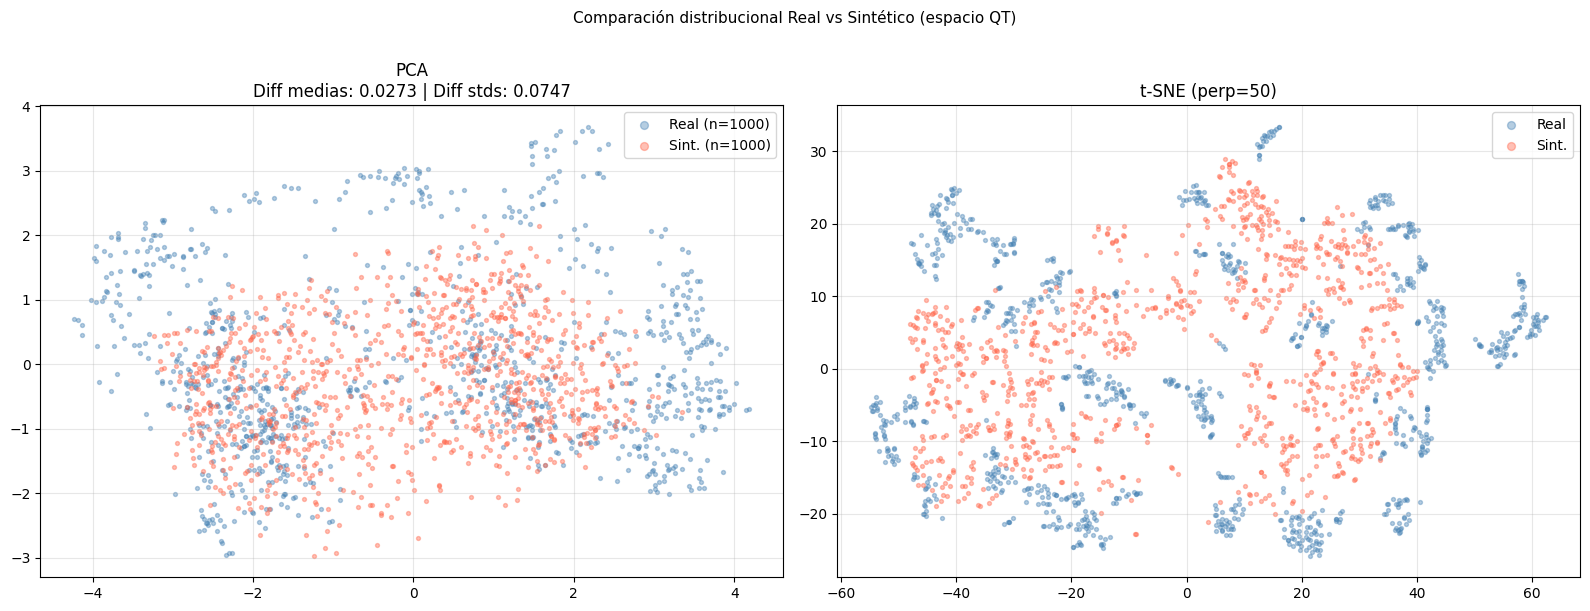

Diff medias: 0.0273  ✅
Diff stds:   0.0747  ✅


In [30]:
n_plot = min(1000, len(train_windows), n_synth)
rng    = np.random.default_rng(SEED)
ri     = rng.choice(len(train_windows), n_plot, replace=False)
si     = rng.choice(n_synth,            n_plot, replace=False)
real_s  = train_windows[ri].reshape(n_plot, -1)
synth_s = synth_qt_corrected[si].reshape(n_plot, -1)
md_diff = np.abs(real_s.mean(0) - synth_s.mean(0)).mean()
sd_diff = np.abs(real_s.std(0)  - synth_s.std(0)).mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
pca_v = PCA(n_components=2, random_state=SEED)
pr = pca_v.fit_transform(real_s); ps = pca_v.transform(synth_s)
axes[0].scatter(pr[:,0], pr[:,1], alpha=0.4, c="steelblue", s=8, label=f"Real (n={n_plot})")
axes[0].scatter(ps[:,0], ps[:,1], alpha=0.4, c="tomato",    s=8, label=f"Sint. (n={n_plot})")
axes[0].set_title(f"PCA\nDiff medias: {md_diff:.4f} | Diff stds: {sd_diff:.4f}")
axes[0].legend(markerscale=2); axes[0].grid(True, alpha=0.3)
comb = PCA(n_components=min(50, real_s.shape[1]), random_state=SEED).fit_transform(
    np.vstack([real_s, synth_s]))
perp = min(50, n_plot // 5)
tout = TSNE(n_components=2, random_state=SEED, perplexity=perp,
            max_iter=2000, init="pca", learning_rate="auto").fit_transform(comb)
axes[1].scatter(tout[:n_plot,0], tout[:n_plot,1], alpha=0.4, c="steelblue", s=8, label="Real")
axes[1].scatter(tout[n_plot:,0], tout[n_plot:,1], alpha=0.4, c="tomato",    s=8, label="Sint.")
axes[1].set_title(f"t-SNE (perp={perp})"); axes[1].legend(markerscale=2); axes[1].grid(True, alpha=0.3)
plt.suptitle("Comparación distribucional Real vs Sintético (espacio QT)", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(str(TIMEGAN_DIR / "tsne_pca.png"), dpi=150, bbox_inches="tight"); plt.show()
print(f"Diff medias: {md_diff:.4f}  {'✅' if md_diff<0.10 else '⚠️'}")
print(f"Diff stds:   {sd_diff:.4f}  {'✅' if sd_diff<0.10 else '⚠️'}")


In [31]:
# Tabla resumen de calidad por sensor
print("=== RESUMEN DE CALIDAD POR SENSOR (espacio QT) ==="); print()
real_flat  = train_windows.reshape(-1, len(GAN_CONT_COLS))
synth_flat = synth_qt_corrected.reshape(-1, len(GAN_CONT_COLS))
print(f'{"Sensor":<20} {"dm":>8} {"ds":>8}  Estado')
print("-" * 45)
quality_rows = []
for j, col in enumerate(GAN_CONT_COLS):
    mr,ms = real_flat[:,j].mean(), synth_flat[:,j].mean()
    sr,ss = real_flat[:,j].std(),  synth_flat[:,j].std()
    dm,ds = abs(mr-ms), abs(sr-ss)
    status = "EXCELENTE" if dm<0.03 and ds<0.03 else "BUENO" if dm<0.07 and ds<0.07 else              "MODERADO" if dm<0.12 else "REVISAR"
    print(f'{col:<20} {dm:>8.4f} {ds:>8.4f}  {status}')
    quality_rows.append({"sensor":col,"diff_mean":dm,"diff_std":ds,"status":status})
quality_df = pd.DataFrame(quality_rows)
print(f"\nDiff medias global: {quality_df['diff_mean'].mean():.4f}")


=== RESUMEN DE CALIDAD POR SENSOR (espacio QT) ===

Sensor                     dm       ds  Estado
---------------------------------------------
LIT101                 0.0259   0.1003  MODERADO
AIT201                 0.0339   0.0308  BUENO
AIT202                 0.0136   0.1287  MODERADO
AIT203                 0.0330   0.0743  MODERADO
DPIT301                0.0745   0.1283  MODERADO
LIT301                 0.0384   0.0613  BUENO
AIT401                 0.0122   0.0507  BUENO
AIT402                 0.0164   0.0877  MODERADO
LIT401                 0.0108   0.0330  BUENO
AIT501                 0.0070   0.1026  MODERADO
AIT502                 0.0316   0.0602  BUENO
AIT503                 0.0422   0.0255  BUENO
AIT504                 0.0187   0.0709  MODERADO
PIT501                 0.0018   0.1043  MODERADO
PIT502                 0.0000   0.0006  EXCELENTE
PIT503                 0.0070   0.1088  MODERADO

Diff medias global: 0.0229


In [32]:
# AUC del RandomForest (referencial -- el TSTR es la métrica definitiva)
X_all = np.vstack([real_s, synth_s]); y_all = np.array([0]*n_plot + [1]*n_plot)
X_tr_rf, X_te_rf, y_tr_rf, y_te_rf = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all)
clf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
clf.fit(X_tr_rf, y_tr_rf)
auc = roc_auc_score(y_te_rf, clf.predict_proba(X_te_rf)[:,1])
fi = clf.feature_importances_; max_fi = fi.max()
print(f"AUC discriminabilidad = {auc:.4f}  (referencial)")
print(f"Importancia máxima RF: {max_fi:.4f}  {'✅' if max_fi<0.05 else '⚠️'}")
print("NOTA: el TSTR es la métrica definitiva, no el AUC del RF.")


AUC discriminabilidad = 1.0000  (referencial)
Importancia máxima RF: 0.0558  ⚠️
NOTA: el TSTR es la métrica definitiva, no el AUC del RF.


## 16. Guardar artefactos

In [33]:
for name, model in [("embedder",embedder),("recovery",recovery),("generator",generator),
                    ("supervisor",supervisor),("discriminator",discriminator)]:
    torch.save(model.state_dict(), TIMEGAN_DIR / f"{name}.pt")

joblib.dump(qt, ARTIFACTS_DIR / "timegan_quantile_transformer.pkl")

with open(TIMEGAN_DIR / "fit_empirical.json", "w") as f:
    json.dump({col: {"p_zero": v["p_zero"], "flow_open_sample": v["flow_open"][:500]}
               for col, v in fit_empirical.items()}, f, indent=2)
with open(TIMEGAN_DIR / "disc_empirical.json", "w") as f:
    json.dump({k: {str(kk): float(vv) for kk,vv in v.items()}
               for k,v in disc_empirical.items()}, f, indent=2)
with open(TIMEGAN_DIR / "discrete_value_maps.json", "w") as f:
    json.dump({k: [float(v) for v in vs] for k,vs in discrete_value_maps.items()}, f, indent=2)

synth_for_det = X_synth_cont  # v3: equivalente a synth_for_det del pipeline anterior
np.save(TIMEGAN_DIR / "synth_qt_raw.npy",       synth_qt_clipped)
np.save(TIMEGAN_DIR / "synth_qt.npy",           synth_qt_corrected)
np.save(TIMEGAN_DIR / "synth_gan_physical.npy", synth_gan_phys)
np.save(TIMEGAN_DIR / "synth_fit_raw.npy",      synth_fit_raw)
np.save(TIMEGAN_DIR / "synth_all_physical.npy", synth_all_phys)
np.save(TIMEGAN_DIR / "synth_for_detector.npy", synth_for_det)
np.save(TIMEGAN_DIR / "X_synth_cont.npy", X_synth_cont)  # (N, T, C) -- listo para LSTM-VAE
np.save(TIMEGAN_DIR / "X_synth_disc.npy", X_synth_disc)  # (N, disc_dim)
np.save(TIMEGAN_DIR / "synth_disc_raw.npy", synth_disc_raw)
synth_disc_summary.to_csv(TIMEGAN_DIR / "synth_disc_summary.csv", index=False)
quality_df.to_csv(TIMEGAN_DIR / "sensor_quality_summary.csv", index=False)

config = {
    "version":           "a1a2_timegan_v5_lstmvae",
    "v2_changes": [
        f"TIMEGAN_STRIDE={TIMEGAN_STRIDE}_reduce_462a38_batches",
        f"epochs_embedder={epochs_embedder}_con_early_stop_factor={EMB_EARLY_STOP_FACTOR}",
        f"R1_INTERVAL={R1_INTERVAL}_calibrado_2.4x_epoca",
        f"epochs_joint={epochs_joint}",
        "hereda_v1_knn_pretrain_iman_conover_detrend_soft"
    ],
    "detector_target":   "lstm_vae_swat_a1a2_baseline_v3",
    "synth_cont_format": "(N, T=10, C=89) -- FE aplicado post-sintesis",
    "dataset":           "SWaT A1/A2 Dec 2015 -- Normal_v1",
    "source_a12":        "Basado en TimeGAN A1A2 v2 + window=10 + FE pipeline v3",
    "window_size":       WINDOW_SIZE,
    "stride_timegan":    TIMEGAN_STRIDE,
    "qt_clip":           [QT_CLIP_LO, QT_CLIP_HI],
    "warmup_sec":        WARMUP_SEC,
    "gan_cont_cols":     GAN_CONT_COLS,
    "fit_bimodal_cols":  FIT_BIMODAL_COLS,
    "discrete_cols":     DISCRETE_COLS,
    "continuous_cols":   CONTINUOUS_COLS,
    "feature_dim":       feature_dim,
    "hidden_dim":        hidden_dim,
    "latent_dim":        latent_dim,
    "num_layers":        num_layers,
    "G_STEPS": G_STEPS, "D_STEPS": D_STEPS, "G_CLIP": G_CLIP, "D_CLIP": D_CLIP,
    "R1_LAMBDA": R1_LAMBDA, "R1_INTERVAL": R1_INTERVAL,
    "gamma": gamma, "eta": eta, "FM_W": FM_W,
    "epochs_embedder":     epochs_embedder,
    "epochs_supervisor":   epochs_supervisor,
    "epochs_joint":        epochs_joint,
    "gen_pretrain_epochs": GEN_PRETRAIN_EPOCHS,
    "batch_size":          BATCH_SIZE,
    "total_train_windows": int(len(train_windows)),
    "n_synth_windows":     n_synth,
    "metrics": {
        "embedder_mse_final":      float(min(embedder_history)),
        "embedder_best_mse":        float(best_emb_mse),
        "embedder_stopped_early":   emb_stopped_early,
        "supervisor_loss_final":   float(supervisor_history[-1]),
        "gen_pretrain_knn_final":  float(pretrain_history[-1]),
        "g_loss_initial":          float(joint_g_history[0]),
        "g_loss_final":            float(joint_g_history[-1]),
        "d_loss_final":            float(joint_d_history[-1]),
        "spikes_g35":              int(sum(1 for g in joint_g_history if g > 3.5)),
        "diff_medias_qt_post_qm":  float(md_diff),
        "diff_stds_qt_post_qm":    float(sd_diff),
        "sensors_corrected":       len(CORRECTION_SENSORS),
        "auc_rf":                  float(auc),
        "rf_importancia_max":      float(max_fi),
    }
}
with open(TIMEGAN_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=4)

pd.DataFrame({"epoch": range(1, len(joint_g_history)+1),
    "g_loss": joint_g_history, "d_loss": joint_d_history, "e_loss": joint_e_history,
}).to_csv(TIMEGAN_DIR / "training_history.csv", index=False)

print("Artefactos guardados en:", TIMEGAN_DIR.resolve())
print()
print(f"  Train windows: {len(train_windows):,} | Batches/epoca: {len(train_loader)}")
print(f"  Embedder best MSE: {best_emb_mse:.6f} | Early stopped: {emb_stopped_early}")
print(f"  Embedder MSE:  {embedder_history[-1]:.6f}")
print(f"  G final:       {joint_g_history[-1]:.4f}  (Nash: {nash_g:.4f})")
print(f"  D final:       {joint_d_history[-1]:.4f}  (Nash: {nash_d:.4f})")
print(f"  Spikes G>3.5:  {int(sum(1 for g in joint_g_history if g > 3.5))}")
print(f"  diff_medias:   {md_diff:.4f}")
print(f"  X_synth_cont:  {X_synth_cont.shape}  (N, T, C) -- LSTM-VAE ready")
print(f"  X_synth_disc:  {X_synth_disc.shape}")
for fp_ in sorted(TIMEGAN_DIR.iterdir()):
    sz = fp_.stat().st_size
    print(f"  {fp_.name:<40} {sz/1e3 if sz<1e6 else sz/1e6:6.1f} {'KB' if sz<1e6 else 'MB'}")


Artefactos guardados en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\timegan\lstm_vae_a1a2_baseline_v5

  Train windows: 11,310 | Batches/epoca: 44
  Embedder best MSE: 0.000202 | Early stopped: False
  Embedder MSE:  0.000206
  G final:       1.3744  (Nash: 1.3863)
  D final:       1.6825  (Nash: 2.0794)
  Spikes G>3.5:  0
  diff_medias:   0.0273
  X_synth_cont:  (33930, 10, 89)  (N, T, C) -- LSTM-VAE ready
  X_synth_disc:  (33930, 104)
  config.json                                 3.4 KB
  disc_empirical.json                         1.6 KB
  discrete_value_maps.json                    0.9 KB
  discriminator.pt                          796.0 KB
  embedder.pt                               689.5 KB
  fit_empirical.json                         79.6 KB
  generator.pt                              764.8 KB
  recovery.pt                               805.2 KB
  sensor_quality_summary.csv                  0.7 KB
  supervisor.pt    